<a href="https://colab.research.google.com/github/tmckim/materials-fa25-colab/blob/main/lec_demos/lec22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Allen Institute Visual Behavior 2P Dataset - Plotting Neural + **Behavioral** Data Demo


Today, we will continue to work with this dataset and plot additional behavioral variables along with the calcium signal from neurons recorded while mice performed a visual discrimination task.


This notebook will help us investigate data collected from the [Visual Behavior 2P](https://allensdk.readthedocs.io/en/latest/visual_behavior_optical_physiology.html) dataset from the Allen Brain Institute.


____
# Learning Objectives

## At the end of this notebook, you'll be able to:
* Plot calcium imaging data based on experimental conditions 🔬 🔎 📈
* Examine the relationship between neuronal responses and beahvior 🧠 🏃 👀 💦
* Understand differences in data format  💭 📓
* Understand how to use common Python packages for data visualization 🐍 💻
* Apply best practices for plotting data 📊 📣
______

## Before you start - Save this notebook!

When you open a new Colab notebook from the WebCampus (like you hopefully did for this one), you cannot save changes. So it's  best to store the Colab notebook in your personal drive `"File > Save a copy in drive..."` **before** you do anything else.

The file will open in a new tab in your web browser, and it is automatically named something like: "**Copy of lec22.ipynb**". You can rename this to just the title of the assignment "**lec22.ipynb**". Make sure you do keep an informative name (like the name of the assignment) so that you know which files to submit back to WebCampus for grading! More instructions on this are at the end of the notebook.


**Where does the notebook get saved in Google Drive?**

By default, the notebook will be copied to a folder called “Colab Notebooks” at the root (home directory) of your Google Drive. If you use this for other courses or personal code notebooks, I recommend creating a folder for this course and then moving the assignments AFTER you have completed them. <br>

I also recommend you give the folder where you save your notebooks^ a different name than the folder we create below that will store the notebook resources you need each time you work through a course notebook. This includes any data files you will need, links to the images that appear in the notebook, and the files associated with the autograder for answer checking.<br>
You should select a name other than '**NS499-DataSci-course-materials**'. <br>
This folder gets overwritten with each assignment you work on in the course, so you should **NOT** store your notebooks in this folder that we use for course materials! <br><br>For example, you could create a folder called 'NS499-**notebooks**' or something along those lines.
___

# Allen Institute Visual Behavior 2P dataset:  Overview reminder
### This dataset consists of neural activity measured with 2-photon calcium imaging in the visual cortex of mice performing an image change detection task. In this task, mice learn to report changes in stimulus identity by licking a spout to earn a water reward.


# Dataset Notes

The entire dataset includes neural and behavioral measurements from:

*   107 mice 🐭
*   4787 behavior training sessions 👀
*   704 *in vivo* imaging sessions 🔬
*   50,482 cortical cells 🧠

The data are openly accessible, and include information about all recorded timeseries, behavioral events, and experimental data in a standard data format: [Neurodata Without Borders (NWB)](https://www.nwb.org/nwb-neurophysiology/).



In this notebook, we are going to focus on the relationship between neural data and behavior metrics.

![](https://allenswdb.github.io/_images/Trial_diagram.png)
<br>
Image [source](https://allenswdb.github.io/physiology/ophys/visual-coding/vc2p-background.html)

# Setup Steps

## Import Data and Files Needed - Optional

Only needed if we have to import the `tidy_df` later if it takes awhile to run the code.

In [ ]:
# Step 1
# Setup and add files needed to access gdrive
from google.colab import drive                                   # these lines mount your gdrive to access the files we import below
drive.mount('/content/gdrive', force_remount=True)

In [ ]:
# Step 2
# Change directory to the correct location in gdrive (modified way to do this from before)
import os
os.chdir('/content/gdrive/MyDrive/NS499-DataSci-course-materials/')

In [ ]:
# Step 3
# Remove the files that were previously there- we will replace with all the old + new ones for this assignment
!rm -r materials-fa24-colab

In [ ]:
# Step 4
# These lines clone (copy) all the files you will need from where I store the code+data for the course (github)
# Second part of the code copies the files to this location and folder in your own gdrive
!git clone https://github.com/tmckim/materials-fa24-colab '/content/gdrive/My Drive/NS499-DataSci-course-materials/materials-fa24-colab/'

In [ ]:
# Step 5
# Change directory into the folder where the resources for this assignment are stored in gdrive (modified way from before)
os.chdir('/content/gdrive/MyDrive/NS499-DataSci-course-materials/materials-fa24-colab/lec_demos/')

## Step 1: Import allensdk

In [ ]:
!pip install allensdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.5/338.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 973.1/973.1 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 80.4 MB/s eta 0:00:0

## Step 2: Set up coding environment
Each time we start an analysis in Python, we must import the necessary code packages. If you're running this notebook in Colab, the cells below will install packages into your coding environment -- these are *not* installed on your computer.

### Import common packages
Below, we'll `import` a common selection of packages that will help us analyze and plot our data. We'll also configure the plotting in our notebook.

*   This will ensure that our coding environment has [NumPy](https://numpy.org/), [Pandas](https://pandas.pydata.org/), [Matplotlib](https://matplotlib.org/), and [Seaborn](https://seaborn.pydata.org/) installed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 500)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

import allensdk
# import pkg_resources # deprecated and no longer needs to be explicitly imported here (but note used below!)
print('allensdk version 2.10.2 or higher is required, you have {} installed'.format(pkg_resources.get_distribution("allensdk").version))

allensdk version 2.10.2 or higher is required, you have 2.16.2 installed


In [ ]:
# Try to make notebook use full screen width
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>.output_result { max-width:100% !important; }</style>")) # output cells

In [ ]:
# Define the path to the data we want to retrieve
output_dir = '/path/to/vbo'
cache = VisualBehaviorOphysProjectCache.from_s3_cache(cache_dir=output_dir)

ophys_session_table.csv: 100%|██████████| 247k/247k [00:00<00:00, 1.14MMB/s] 
behavior_session_table.csv: 100%|██████████| 1.59M/1.59M [00:00<00:00, 7.56MMB/s]
ophys_experiment_table.csv: 100%|██████████| 657k/657k [00:00<00:00, 2.84MMB/s] 
ophys_cells_table.csv: 100%|██████████| 4.28M/4.28M [00:00<00:00, 10.3MMB/s]
/usr/local/lib/python3.10/dist-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_

In [ ]:
# get metadata tables
behavior_session_table = cache.get_behavior_session_table()
ophys_session_table = cache.get_ophys_session_table()
ophys_experiment_table = cache.get_ophys_experiment_table()

#print number of items in each table for all imaging and behavioral sessions
print('Number of behavior sessions = {}'.format(len(behavior_session_table)))
print('Number of ophys sessions = {}'.format(len(ophys_session_table)))
print('Number of ophys experiments = {}'.format(len(ophys_experiment_table)))

Number of behavior sessions = 4782
Number of ophys sessions = 703
Number of ophys experiments = 1936


* behavior session table: full training history of each mouse and is organized by `behavior_session_id`.
  * `Session_types` under 2P begin with `OPHYS_` and have an `ophys_session_id` if the data passed quality control and is available for analysis

In [ ]:
behavior_session_table

,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_plane_group_count,project_code,session_type,session_number,image_set,behavior_type,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,num_depths_per_area,ophys_experiment_id,num_targeted_structures,correct_reject_trial_count,hit_trial_count,file_id,false_alarm_trial_count,catch_trial_count,go_trial_count,miss_trial_count,trial_count,engaged_trial_count
behavior_session_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
870987812,<NA>,NaN,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,80,<NA>,VisualBehaviorMultiscope,TRAINING_0_gratings_autorewards_15min,<NA>,gratings,active_behavior,Training,0,<NA>,0,2019-05-17 14:46:33.550000+00:00,BEH.D-Box1,<NA>,NaN,<NA>,0,0,1941,0,0,0,0,121,70
872953842,<NA>,NaN,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,84,<NA>,VisualBehaviorMultiscope,TRAINING_1_gratings,<NA>,gratings,active_behavior,Training,0,<NA>,0,2019-05-21 13:22:20.613000+00:00,BEH.D-Box1,<NA>,NaN,<NA>,45,18,1942,4,49,293,275,564,27
873774125,<NA>,NaN,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,85,<NA>,VisualBehaviorMultiscope,TRAINING_1_gratings,<NA>,gratings,active_behavior,Training,1,<NA>,0,2019-05-22 13:19:52.005000+00:00,BEH.D-Box1,<NA>,NaN,<NA>,38,14,1943,3,41,314,300,548,0
874790261,<NA>,NaN,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,86,<NA>,VisualBehaviorMultiscope,TRAINING_1_gratings,<NA>,gratings,active_behavior,Training,2,<NA>,0,2019-05-23 13:40:31.405000+00:00,BEH.D-Box1,<NA>,NaN,<NA>,42,14,1944,0,42,326,312,492,0
875207834,<NA>,NaN,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,87,<NA>,VisualBehaviorMultiscope,TRAINING_1_gratings,<NA>,gratings,active_behavior,Training,3,<NA>,0,2019-05-24 11:06:39.332000+00:00,BEH.D-Box1,<NA>,NaN,<NA>,41,22,1945,3,44,322,300,504,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993537991,993512923,[991913246],489066,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,128,<NA>,VisualBehaviorTask1B,OPHYS_2_images_B_passive,2,images_B,passive_viewing,Familiar,0,12,2,2019-12-10 12:25:49.549000+00:00,CAM2P.4,1,[993590480],1,52,0,-999,0,52,357,357,410,0
993691759,993668836,[991913246],489066,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,129,<NA>,VisualBehaviorTask1B,OPHYS_4_images_A,4,images_A,active_behavior,Novel 1,0,0,3,2019-12-11 08:57:44.877000+00:00,CAM2P.4,1,[993862120],1,20,86,-999,6,26,200,114,725,314
993959724,993948045,[991913246],489066,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,130,<NA>,VisualBehaviorTask1B,OPHYS_5_images_A_passive,5,images_A,passive_viewing,Novel >1,0,1,4,2019-12-12 09:29:20.785000+00:00,CAM2P.4,1,[994053909],1,49,0,-999,0,49,353,353,402,0


In [ ]:
behavior_session_table.shape

(4782, 34)

* ophys session table: metadata for each imaging session
  * organized by `ophys_session_id`

In [ ]:
ophys_session_table

,behavior_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_plane_group_count,project_code,session_type,session_number,image_set,behavior_type,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,num_depths_per_area,ophys_experiment_id,num_targeted_structures
ophys_session_id,,,,,,,,,,,,,,,,,,,,,,,,,
951410079,951520319,"[1018028339, 1018028342, 1018028345, 101802835...",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,4,VisualBehaviorMultiscope,OPHYS_1_images_A,1,images_A,active_behavior,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,4,"[951980471, 951980473, 951980475, 951980479, 9...",2
952430817,952554548,"[1018028339, 1018028345, 1018028354, 1018028357]",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,209,3,VisualBehaviorMultiscope,OPHYS_2_images_A_passive,2,images_A,passive_viewing,Familiar,0,66,1,2019-09-23 08:45:38.490000+00:00,MESO.1,4,"[953659743, 953659745, 953659749, 953659752]",2
954954402,953982960,"[1018028339, 1018028342, 1018028345, 101802835...",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,210,4,VisualBehaviorMultiscope,OPHYS_3_images_A,3,images_A,active_behavior,Familiar,0,67,2,2019-09-24 09:01:31.582000+00:00,MESO.1,4,"[958527464, 958527471, 958527474, 958527479, 9...",2
955775716,956010809,"[1018028339, 1018028342, 1018028345]",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,212,2,VisualBehaviorMultiscope,OPHYS_3_images_A,3,images_A,active_behavior,Familiar,1,68,3,2019-09-26 09:22:21.772000+00:00,MESO.1,4,"[956941841, 956941844, 956941846]",2
957020350,957032492,"[1018028339, 1018028342, 1018028345, 101802835...",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,213,4,VisualBehaviorMultiscope,OPHYS_4_images_B,4,images_B,active_behavior,Novel 1,0,0,4,2019-09-27 08:58:37.005000+00:00,MESO.1,4,"[957759562, 957759564, 957759566, 957759570, 9...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038121306,1038138169,[1036303886],512458,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"[Slc17a7-IRES2-Cre, Camk2a-tTA]",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),F,206,<NA>,VisualBehaviorTask1B,OPHYS_3_images_B,3,images_B,active_behavior,Familiar,0,28,3,2020-07-23 13:58:13.416000+00:00,CAM2P.3,1,[1038171965],1
1038295095,1038309505,[1036303886],512458,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"[Slc17a7-IRES2-Cre, Camk2a-tTA]",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),F,207,<NA>,VisualBehaviorTask1B,OPHYS_4_images_A,4,images_A,active_behavior,Novel 1,0,0,4,2020-07-24 13:40:43.045000+00:00,CAM2P.3,1,[1038360130],1
1038779134,1038793248,[1036303886],512458,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"[Slc17a7-IRES2-Cre, Camk2a-tTA]",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),F,210,<NA>,VisualBehaviorTask1B,OPHYS_2_images_B_passive,2,images_B,passive_viewing,Familiar,1,29,5,2020-07-27 12:18:25.309000+00:00,CAM2P.3,1,[1038848242],1


In [ ]:
ophys_session_table.shape

(703, 25)

* ophys experiment table: metadata for each imaging plane in each session
  * organized by `ophys_experiment_id`
  * includes all data as in the `ophys_session_table` + info specific to the imaging plane: `imaging_depth` and `targeted_structure`

In [ ]:
ophys_experiment_table


,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_depth,targeted_structure,targeted_imaging_depth,imaging_plane_group,project_code,session_type,session_number,image_set,behavior_type,passive,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,published_at,isi_experiment_id,file_id
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
951980471,951520319,951410079,1018028342,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,150,VISp,150,0,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,0
951980473,951520319,951410079,1018028345,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISp,225,0,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,1
951980475,951520319,951410079,1018028339,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,75,VISp,75,1,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,2
951980479,951520319,951410079,1018028354,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,150,VISl,150,2,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,3
951980481,951520319,951410079,1018028357,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISl,225,2,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993590480,993537991,993512923,991913246,489066,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,128,175,VISp,175,<NA>,VisualBehaviorTask1B,OPHYS_2_images_B_passive,2,B,passive_viewing,True,Familiar,0,12,2,2019-12-10 12:25:49.549000+00:00,CAM2P.4,2021-03-25,967103425,1917
993862120,993691759,993668836,991913246,489066,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,129,175,VISp,175,<NA>,VisualBehaviorTask1B,OPHYS_4_images_A,4,A,active_behavior,False,Novel 1,0,0,3,2019-12-11 08:57:44.877000+00:00,CAM2P.4,2021-03-25,967103425,1918
994053909,993959724,993948045,991913246,489066,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,130,175,VISp,175,<NA>,VisualBehaviorTask1B,OPHYS_5_images_A_passive,5,A,passive_viewing,True,Novel >1,0,1,4,2019-12-12 09:29:20.785000+00:00,CAM2P.4,2021-03-25,967103425,1919


In [ ]:
ophys_experiment_table.shape

(1936, 30)

## SST Neuron - is activity related to behavior?

Filter data to select subset - get `ophys_experiment_id`s corresponding to specific experimental conditions by filtering the table using the columns: <br>

* mice from the Sst-IRES-Cre Driver Line: `cre_line`
* `session_number` to identify experiments from the first session with the novel images
  * always has a `session_type` starting with `OPHYS_4`
  * use  abbreviated `session_number` column (agnostic to which specific image set was used)
* `prior_exposures_to_image_set`: select a session that was the first day with the novel image set (not a retake of the same `session_type`)

In [ ]:
# get all Sst experiments for ophys session 4 (novel images)
selected_experiment_table = ophys_experiment_table[(ophys_experiment_table.cre_line=='Sst-IRES-Cre')&
                        (ophys_experiment_table.session_number==4) &
                        (ophys_experiment_table.prior_exposures_to_image_set==0)]
print('Number of experiments: {}'.format(len(selected_experiment_table)))

Number of experiments: 58


Remember that any given experiment (defined by its ophys_experiment_id) contains data from only one imaging plane, in one session. There can be multiple experiments (imaging planes) recorded in the same imaging session if the multi-plane 2-photon microscope was used, but there can never be multiple sessions for a given ophys_experiment_id.

In [ ]:
print('Number of unique sessions: {}'.format(len(selected_experiment_table['ophys_session_id'].unique())))

Number of unique sessions: 19


We will randomly select data from an experiment- I've already pre-selected one below for us.

In [ ]:
# load the data for this ophys experiment from the cache
ophys_experiment_id = 957759570
ophys_experiment = cache.get_behavior_ophys_experiment(ophys_experiment_id)

behavior_ophys_experiment_957759570.nwb: 100%|██████████| 268M/268M [00:16<00:00, 16.1MMB/s]
/usr/local/lib/python3.10/dist-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


The `get_behavior_ophys_experiment()` method returns a python object containing all data and metadata for the provided `ophys_experiment_id`.

In [ ]:
ophys_experiment.metadata

{'equipment_name': 'MESO.1',
 'sex': 'F',
 'age_in_days': 213,
 'stimulus_frame_rate': 60.0,
 'session_type': 'OPHYS_4_images_B',
 'date_of_acquisition': datetime.datetime(2019, 9, 27, 8, 58, 37, 5000, tzinfo=tzlocal()),
 'reporter_line': 'Ai148(TIT2L-GC6f-ICL-tTA2)',
 'cre_line': 'Sst-IRES-Cre',
 'behavior_session_uuid': UUID('40897cd4-3279-4a2d-b65d-b3f984e34e17'),
 'driver_line': ['Sst-IRES-Cre'],
 'mouse_id': '457841',
 'project_code': 'VisualBehaviorMultiscope',
 'full_genotype': 'Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt',
 'behavior_session_id': 957032492,
 'indicator': 'GCaMP6f',
 'emission_lambda': 520.0,
 'excitation_lambda': 910.0,
 'ophys_container_id': 1018028354,
 'field_of_view_height': 512,
 'field_of_view_width': 512,
 'imaging_depth': 150,
 'targeted_imaging_depth': 150,
 'imaging_plane_group': 2,
 'imaging_plane_group_count': 4,
 'ophys_experiment_id': 957759570,
 'ophys_frame_rate': 11.0,
 'ophys_session_id': 957020350,
 'targeted_structure': 'VISl'}

In the next steps, we want to combine various sources of data into a single plot: <br>
* `dff_traces`
* `events`
* `running_speed`
* `pupil_area`
* `stimulus_presentations`

---
## Data Review: Images
`stimulus_presentations` has some NaN values. We need to remove those rows of the data because they correspond to other conditions we aren't interested in (initial_gray_screen_5min, natural_movie, etc)

In [ ]:
# review this data and see NaNs
ophys_experiment.stimulus_presentations

,stimulus_block,stimulus_block_name,image_index,image_name,movie_frame_index,duration,start_time,end_time,start_frame,end_frame,is_change,is_image_novel,omitted,movie_repeat,flashes_since_change,trials_id,stimulus_name,active,is_sham_change
stimulus_presentations_id,,,,,,,,,,,,,,,,,,,
0,0,initial_gray_screen_5min,-99,NaN,-99,308.772448,0.000000,308.772448,0,17985,False,<NA>,<NA>,-99,0,-99,spontaneous,False,False
1,1,change_detection_behavior,0,im000,-99,0.250210,308.772448,309.022658,17985,18000,False,True,False,-99,1,0,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False
2,1,change_detection_behavior,0,im000,-99,0.250180,309.523058,309.773238,18030,18045,False,True,False,-99,2,0,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False
3,1,change_detection_behavior,0,im000,-99,0.250160,310.273688,310.523848,18075,18090,False,True,False,-99,3,1,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False
4,1,change_detection_behavior,0,im000,-99,0.250220,311.024258,311.274478,18120,18135,False,True,False,-99,4,1,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13794,3,natural_movie_one,-99,NaN,895,0.033340,4510.138358,4510.171698,269861,269862,False,<NA>,<NA>,9,9002,-99,natural_movie_one,False,False
13795,3,natural_movie_one,-99,NaN,896,0.033360,4510.171698,4510.205058,269863,269864,False,<NA>,<NA>,9,9003,-99,natural_movie_one,False,False
13796,3,natural_movie_one,-99,NaN,897,0.033370,4510.205058,4510.238428,269865,269866,False,<NA>,<NA>,9,9004,-99,natural_movie_one,False,False


In [ ]:
# how many unique options are there?
ophys_experiment.stimulus_presentations['image_name'].unique()

array([nan, 'im000', 'im031', 'omitted', 'im054', 'im073', 'im106',
       'im075', 'im045', 'im035'], dtype=object)

To remove these from the data we will work with, there are multiple options:
1. Remove rows with NaNs in our column of interest
2. Filter based on the `stimulus_block_name` column for `change_detection_behavior`

In [ ]:
# 1: Select data that are not null (all except NaNs) in image_name col
# dataframe
all_stim = ophys_experiment.stimulus_presentations

# remove the Nans- effectively selecting only stimulus_block_name that is change_detection_behavior
all_stim = all_stim[all_stim['image_name'].notnull()]

Check the results before proceeding

In [ ]:
all_stim['image_name'].unique()

array(['im000', 'im031', 'omitted', 'im054', 'im073', 'im106', 'im075',
       'im045', 'im035'], dtype=object)

In [ ]:
all_stim['stimulus_block_name'].unique()

array(['change_detection_behavior'], dtype=object)

^ the `all_stim` dataframe is the one we will use in the code below

### Another example of creating the same dataframe from above

In [ ]:
# 2: Filter based on stimulus_block_name
# dataframe
stim = ophys_experiment.stimulus_presentations

# remove the Nans- effectively selecting only stimulus_block_name that is change_detection_behavior
stim_another_way = stim[stim['stimulus_block_name'] == 'change_detection_behavior']

Check the results before proceeding

In [ ]:
stim_another_way['image_name'].unique()

array(['im000', 'im031', 'omitted', 'im054', 'im073', 'im106', 'im075',
       'im045', 'im035'], dtype=object)

In [ ]:
stim_another_way['stimulus_block_name'].unique()

array(['change_detection_behavior'], dtype=object)

---
## Data Prep: Defining Colors for Each Image
Data preparation for plotting- we will add a list of colors for each image. This will appear as a vertical bar on our plots to indicate the time the image was shown, and to visually identify when images changed or stayed the same.

In [ ]:
#@title Hidden Code
# create a list of all unique stimuli presented in this experiment
unique_stimuli = [stimulus for stimulus in all_stim['image_name'].unique()]

# create a colormap with each unique image having its own color
colormap = {image_name: sns.color_palette()[image_number] for image_number, image_name in enumerate(np.sort(unique_stimuli))}
colormap['omitted'] = (1,1,1) # set omitted stimulus to white color

# add the colors for each image to the stimulus presentations table in the dataset
stimulus_presentations = all_stim
stimulus_presentations['color'] = all_stim['image_name'].map(lambda image_name: colormap[image_name])

This is new and something we haven't covered: [list comprehension](https://www.geeksforgeeks.org/python-list-comprehension/)

## Walk through of the above cells- Optional

In [ ]:
# create a list of all unique stimuli presented in this experiment
unique_stimuli = [stimulus for stimulus in all_stim['image_name'].unique()]
unique_stimuli

['im000',
 'im031',
 'omitted',
 'im054',
 'im073',
 'im106',
 'im075',
 'im045',
 'im035']

In [ ]:
# create a colormap with each unique image having its own color- this is a dict
# note here we also use seaborn color palettes - sns
colormap = {image_name: sns.color_palette()[image_number] for image_number, image_name in enumerate(np.sort(unique_stimuli))}
colormap

{'im000': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'im031': (1.0, 0.4980392156862745, 0.054901960784313725),
 'im035': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'im045': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'im054': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'im073': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'im075': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 'im106': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 'omitted': (0.7372549019607844, 0.7411764705882353, 0.13333333333333333)}

In [ ]:
colormap['omitted'] = (1,1,1) # set omitted stimulus to white color
colormap

{'im000': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'im031': (1.0, 0.4980392156862745, 0.054901960784313725),
 'im035': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'im045': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'im054': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'im073': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'im075': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 'im106': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 'omitted': (1, 1, 1)}

These lines are also advanced and topics we haven't covered. `lambda` is used for an [anonymous function](https://www.geeksforgeeks.org/python-list-comprehension/) along with the [`.map`](https://pandas.pydata.org/docs/dev/reference/api/pandas.DataFrame.map.html) method in `pandas`

In [ ]:
# add the colors for each image to the stimulus presentations table in the dataset
stimulus_presentations = all_stim
stimulus_presentations['color'] = all_stim['image_name'].map(lambda image_name: colormap[image_name])

## Review Data: New Color Column
You can review the dataframe `stimulus_presentations` to see what we did- we added a color column that has color info depending on the image.

In [ ]:
stimulus_presentations

,stimulus_block,stimulus_block_name,image_index,image_name,movie_frame_index,duration,start_time,end_time,start_frame,end_frame,is_change,is_image_novel,omitted,movie_repeat,flashes_since_change,trials_id,stimulus_name,active,is_sham_change,color
stimulus_presentations_id,,,,,,,,,,,,,,,,,,,,
1,1,change_detection_behavior,0,im000,-99,0.25021,308.772448,309.022658,17985,18000,False,True,False,-99,1,0,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False,"(0.12156862745098039, 0.4666666666666667, 0.70..."
2,1,change_detection_behavior,0,im000,-99,0.25018,309.523058,309.773238,18030,18045,False,True,False,-99,2,0,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False,"(0.12156862745098039, 0.4666666666666667, 0.70..."
3,1,change_detection_behavior,0,im000,-99,0.25016,310.273688,310.523848,18075,18090,False,True,False,-99,3,1,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False,"(0.12156862745098039, 0.4666666666666667, 0.70..."
4,1,change_detection_behavior,0,im000,-99,0.25022,311.024258,311.274478,18120,18135,False,True,False,-99,4,1,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False,"(0.12156862745098039, 0.4666666666666667, 0.70..."
5,1,change_detection_behavior,0,im000,-99,0.25021,311.774888,312.025098,18165,18180,False,True,False,-99,5,1,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False,"(0.12156862745098039, 0.4666666666666667, 0.70..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4793,1,change_detection_behavior,7,im035,-99,0.25021,3906.295048,3906.545258,233660,233675,False,True,False,-99,1,639,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False,"(0.17254901960784313, 0.6274509803921569, 0.17..."
4794,1,change_detection_behavior,7,im035,-99,0.25020,3907.045668,3907.295868,233705,233720,False,True,False,-99,2,639,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False,"(0.17254901960784313, 0.6274509803921569, 0.17..."
4795,1,change_detection_behavior,7,im035,-99,0.25022,3907.796278,3908.046498,233750,233765,False,True,False,-99,3,639,Natural_Images_Lum_Matched_set_ophys_6_2017,True,False,"(0.17254901960784313, 0.6274509803921569, 0.17..."


## Define Plotting Functions

This is code to define individual functions for each type of the data we want to plot: <br>
* `dff_traces` - calcium florescence signal
* `events` - timing and magnitude of calcium signals
  * exclude prolonged calcium transients that may contaminate neural responses to subsequent stimuli
* `running speed` - running speed (cm/s)
* `pupil area` - pupil area (px sq)
* `licks` - timing of licking behavior
* `rewards` - timing of reward delivery
* `stimuli` - color coded images for plot

This enables us to just reuse the code to make the plot below, but select different cells to plot!


In [ ]:
#@title Hidden Functions
# function to plot dff traces
def plot_dff_trace(ax, cell_specimen_id, initial_time, final_time):
    '''
        ax: axis on which to plot
        cell_specimen_id: id of the cell to plot
        intial_time: initial time to plot from
        final_time: final time to plot to
    '''
    # create a dataframe using dff trace from one selected cell
    data = {'dff': ophys_experiment.dff_traces.loc[cell_specimen_id]['dff'],
        'timestamps': ophys_experiment.ophys_timestamps}
    df = pd.DataFrame(data)
    dff_trace_sample = df[(df.timestamps >= initial_time) & (df.timestamps <= final_time)]
    ax.plot(dff_trace_sample['timestamps'], dff_trace_sample['dff']/dff_trace_sample['dff'].max())

# function to plot events traces
def plot_events_trace(ax, cell_specimen_id, initial_time, final_time):
    # create a dataframe using events trace from one selected cell
    data = {'events': ophys_experiment.events.loc[cell_specimen_id].events,
        'timestamps': ophys_experiment.ophys_timestamps}
    df = pd.DataFrame(data)
    events_trace_sample = df[(df.timestamps >= initial_time) & (df.timestamps <= final_time)]
    ax.plot(events_trace_sample['timestamps'], events_trace_sample['events']/events_trace_sample['events'].max())

# function to plot running speed
def plot_running(ax, initial_time, final_time):
    running_sample = ophys_experiment.running_speed.copy()
    running_sample = running_sample[(running_sample.timestamps >= initial_time) & (running_sample.timestamps <= final_time)]
    ax.plot(running_sample['timestamps'], running_sample['speed']/running_sample['speed'].max(),
            '--', color = 'gray', linewidth = 1)

# function to plot pupil diameter
def plot_pupil(ax, initial_time, final_time):
    pupil_sample = ophys_experiment.eye_tracking.copy()
    pupil_sample = pupil_sample[(pupil_sample.timestamps >= initial_time) &
                                (pupil_sample.timestamps <= final_time)]
    ax.plot(pupil_sample['timestamps'], pupil_sample['pupil_width']/pupil_sample['pupil_width'].max(),
            color = 'gray', linewidth = 1)

# function to plot licks
def plot_licks(ax, initial_time, final_time):
    licking_sample = ophys_experiment.licks.copy()
    licking_sample = licking_sample[(licking_sample.timestamps >= initial_time) &
                                    (licking_sample.timestamps <= final_time)]
    ax.plot(licking_sample['timestamps'], np.zeros_like(licking_sample['timestamps']),
            marker = 'o', markersize = 3, color = 'black', linestyle = 'none')

# function to plot rewards
def plot_rewards(ax, initial_time, final_time):
    rewards_sample = ophys_experiment.rewards.copy()
    rewards_sample = rewards_sample[(rewards_sample.timestamps >= initial_time) &
                                    (rewards_sample.timestamps <= final_time)]
    ax.plot(rewards_sample['timestamps'], np.zeros_like(rewards_sample['timestamps']),
            marker = 'd', color = 'blue', linestyle = 'none', markersize = 12, alpha = 0.5)

# function to plot stimuli
def plot_stimuli(ax, initial_time, final_time):
    stimulus_presentations_sample = stimulus_presentations.copy()
    stimulus_presentations_sample = stimulus_presentations_sample[(stimulus_presentations_sample.end_time >= initial_time) & (stimulus_presentations_sample.start_time <= final_time)]
    for idx, stimulus in stimulus_presentations_sample.iterrows():
        ax.axvspan(stimulus['start_time'], stimulus['end_time'], color=stimulus['color'], alpha=0.25)

In [ ]:
# get list of cell_specimen_ids using the index of cell_specimen_table- we choose one below
cell_specimen_ids = ophys_experiment.cell_specimen_table.index.values
cell_specimen_ids

array([1086607071, 1086607143, 1086607340, 1086607562, 1086608432,
       1086610383, 1086607814, 1086608913, 1086608195, 1086607431,
       1086607903, 1086609334, 1086606974, 1086607195, 1086608294,
       1086610611, 1086608811, 1086608379, 1086610696, 1086608491,
       1086609380, 1086608577, 1086608630])

In [ ]:
len(cell_specimen_ids)

23

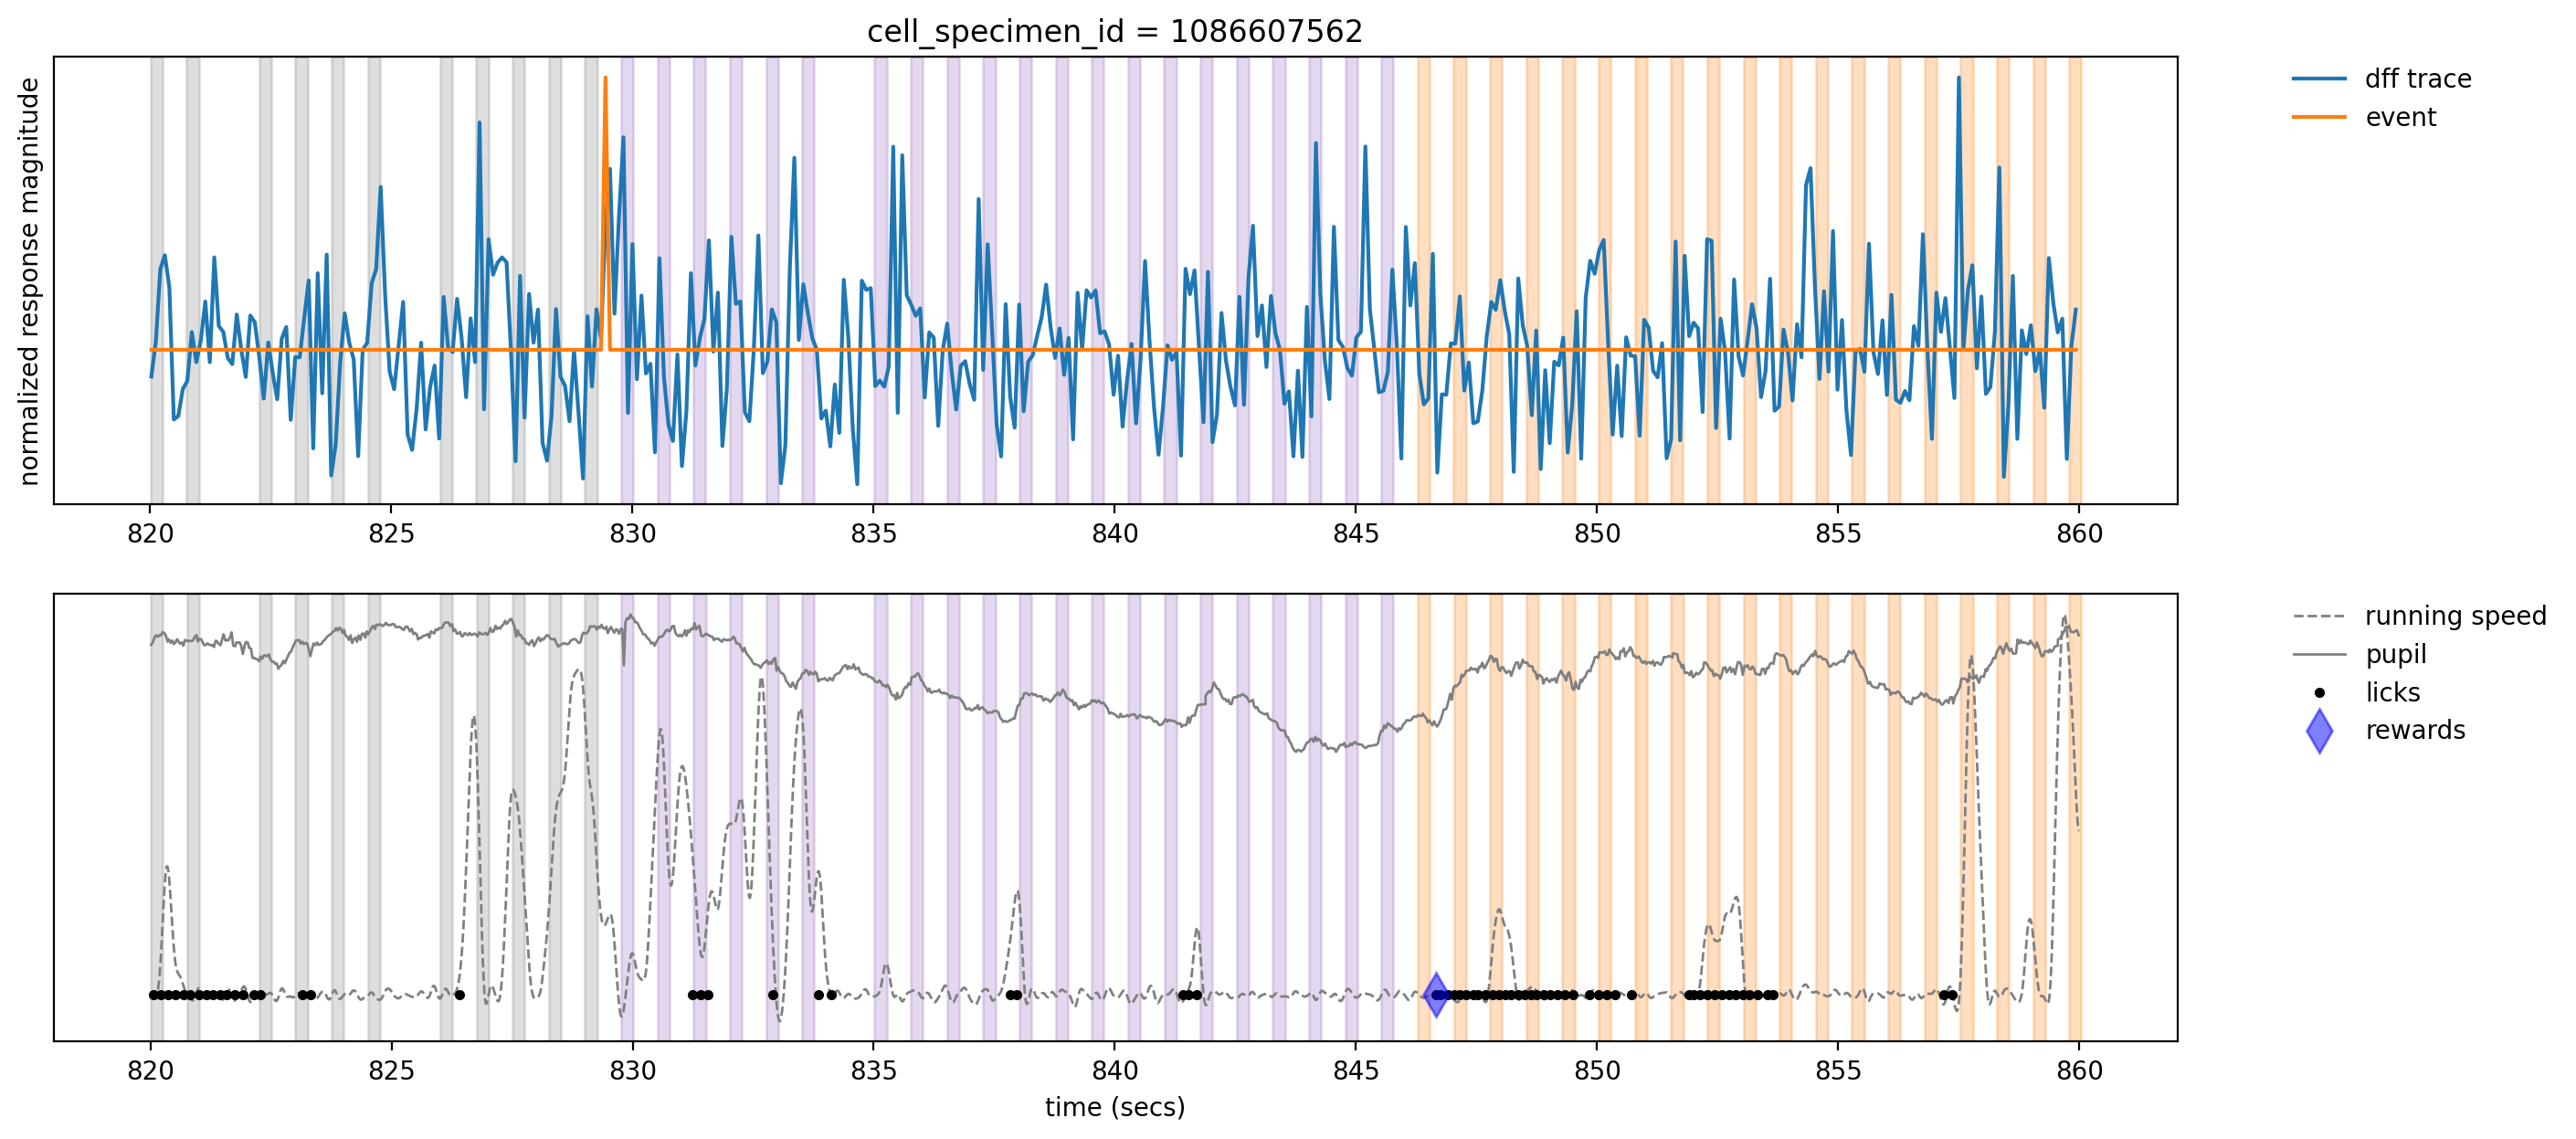

In [ ]:
# Plotting code

# change the id here whenever you want to generate a new plot
cell_id = cell_specimen_ids[3]

initial_time = 820 # start time in seconds
final_time = 860 # stop time in seconds

fig, ax = plt.subplots(2,1,figsize = (15,7))

plot_dff_trace(ax[0], cell_id, initial_time, final_time)
plot_events_trace(ax[0], cell_id, initial_time, final_time)
plot_stimuli(ax[0], initial_time, final_time)
ax[0].set_ylabel('normalized response magnitude')
ax[0].set_yticks([])
ax[0].set_title('cell_specimen_id = '+ str(cell_id))
ax[0].legend(['dff trace', 'event'], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, frameon = False)

plot_running(ax[1], initial_time, final_time)
plot_pupil(ax[1], initial_time, final_time)
plot_licks(ax[1], initial_time, final_time)
plot_rewards(ax[1], initial_time, final_time)
plot_stimuli(ax[1], initial_time, final_time)

ax[1].set_yticks([])
ax[1].set_xlabel('time (secs)')
ax[1].legend(['running speed', 'pupil','licks', 'rewards'],bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, frameon = False);

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
What do you see in this plot? </div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
#@title Hidden
# This SST neuron (13-14 minutes into session)::
# active during our experiment but its activity does not appear to be reliably locked to image presentations
# might follow animal's running speed - could be modulated by running instead

---
## Which images were shown on the trials above?

What if we want to know which images were shown here?

In [ ]:
 # from the stimulus presentation function to plot
stimulus_presentations_plot = stimulus_presentations.copy()
stimulus_presentations_plot = stimulus_presentations_plot[(stimulus_presentations_plot.end_time >= initial_time) & (stimulus_presentations_plot.start_time <= final_time)]
stimulus_presentations_plot.image_name.unique()

array(['im106', 'omitted', 'im054', 'im031'], dtype=object)

Here is the table with this info- we an then use indices to find the data to plot for each image.

In [ ]:
ophys_experiment.stimulus_templates

,unwarped,warped
image_name,,
im000,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[122, 122, 123, 125, 126, 127, 128, 129, 130,..."
im106,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[108, 109, 106, 103, 102, 104, 107, 112, 117,..."
im075,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[120, 121, 121, 121, 122, 123, 123, 122, 121,..."
im073,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[120, 120, 118, 116, 116, 119, 121, 120, 117,..."
im045,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[10, 13, 6, 0, 0, 8, 15, 13, 6, 2, 4, 9, 12, ..."
im054,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[124, 125, 127, 130, 133, 134, 136, 138, 140,..."
im031,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[233, 234, 244, 253, 253, 244, 237, 239, 246,..."
im035,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[178, 181, 189, 198, 200, 198, 196, 199, 205,..."


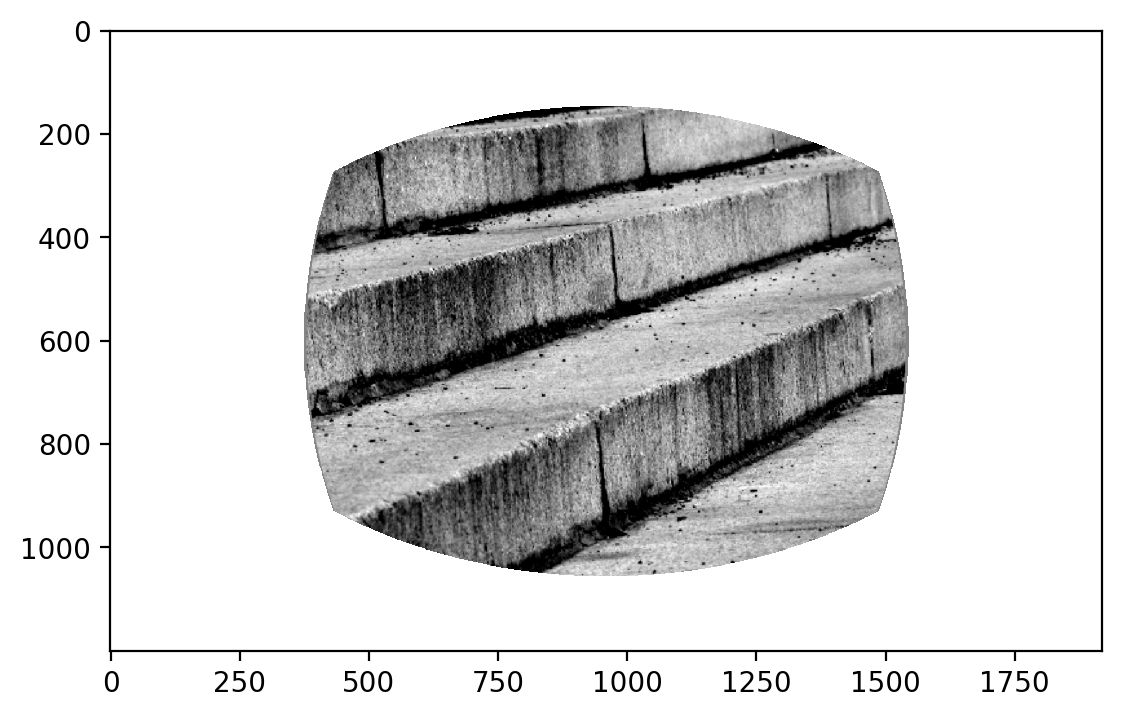

In [ ]:
# im106 is index 1
stimulus_templates = ophys_experiment.stimulus_templates.copy()
stimuli = stimulus_templates.index.values
plt.imshow(stimulus_templates.loc[stimuli[1]]['unwarped'], cmap='gray');

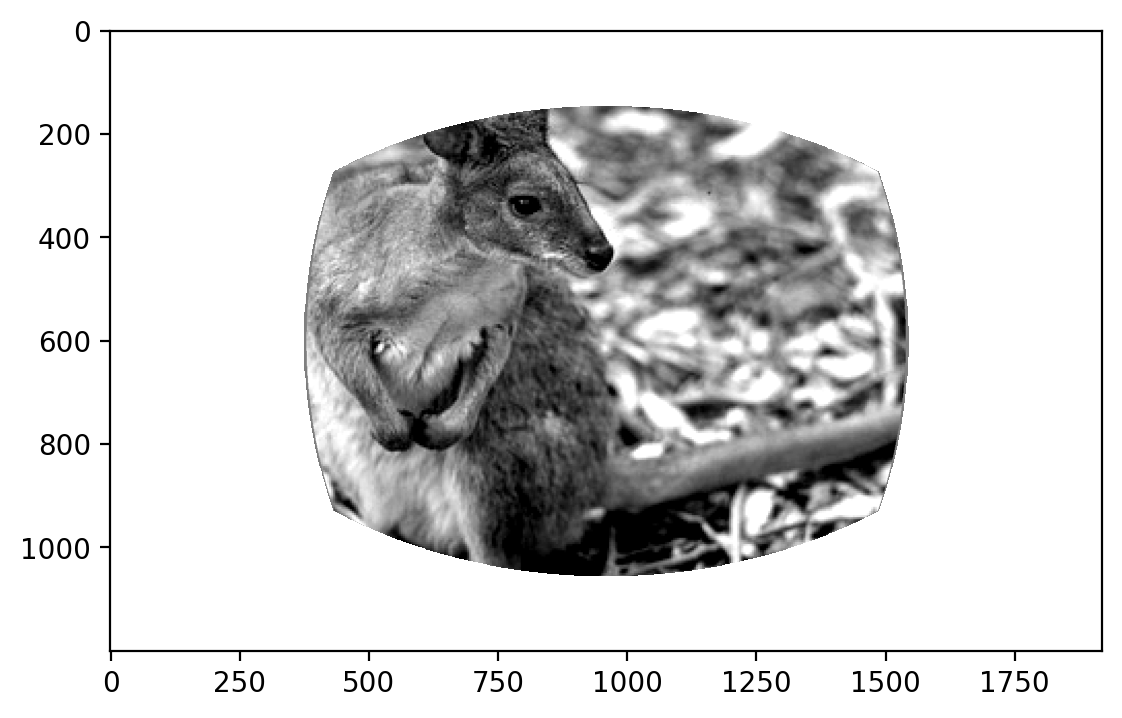

In [ ]:
# im054 is index 5
stimulus_templates = ophys_experiment.stimulus_templates.copy()
stimuli = stimulus_templates.index.values
plt.imshow(stimulus_templates.loc[stimuli[5]]['unwarped'], cmap='gray');

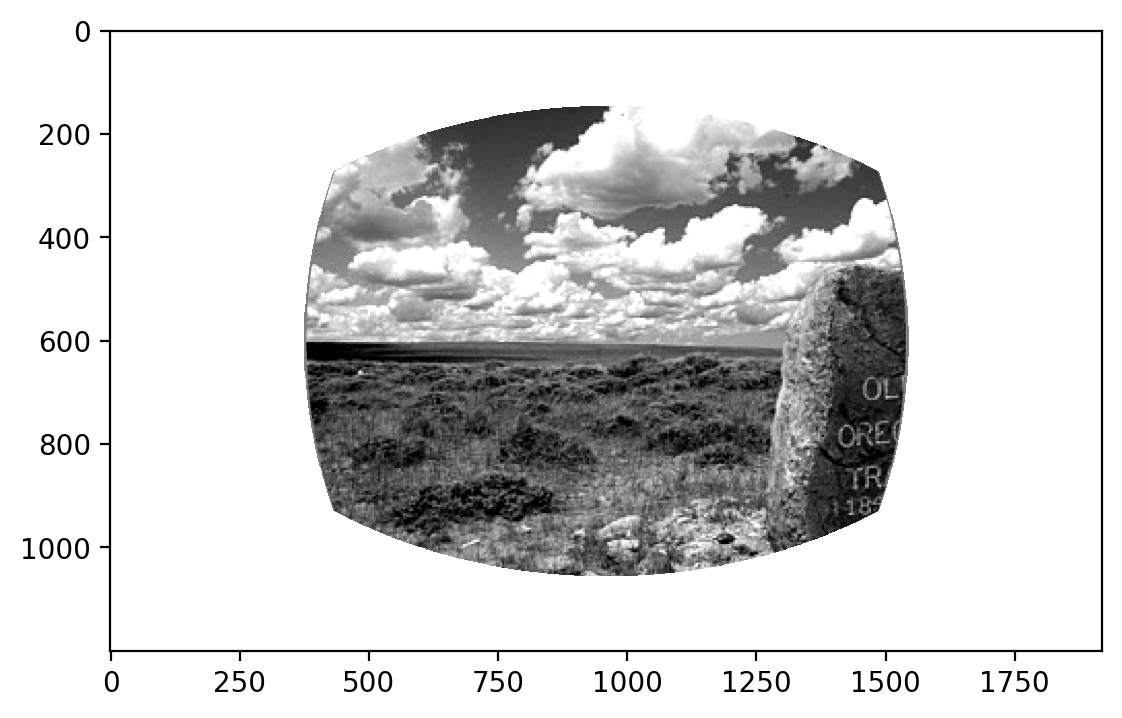

In [ ]:
# im031 is index 6
stimulus_templates = ophys_experiment.stimulus_templates.copy()
stimuli = stimulus_templates.index.values
plt.imshow(stimulus_templates.loc[stimuli[6]]['unwarped'], cmap='gray');

## Dff vs events

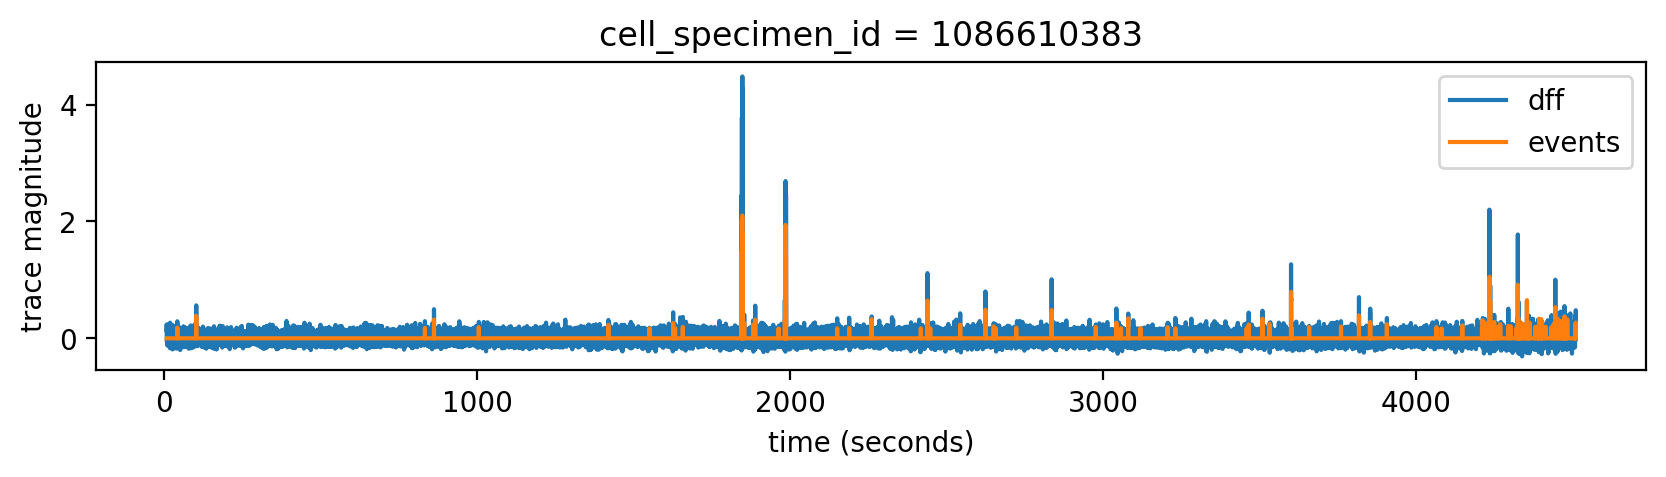

In [ ]:
#@title Hidden Code - dff and events
# plot dff and events traces overlaid from the cell selected above
fig, ax = plt.subplots(1,1, figsize = (10,2))
ax.plot(ophys_experiment.ophys_timestamps, ophys_experiment.dff_traces.loc[cell_specimen_id, 'dff'], label='dff')
ax.plot(ophys_experiment.ophys_timestamps, ophys_experiment.events.loc[cell_specimen_id, 'events'], label='events')
ax.set_xlabel('time (seconds)')
ax.set_ylabel('trace magnitude')
ax.set_title('cell_specimen_id = '+str(cell_specimen_id))
ax.legend();

---
## VIP Neuron - is activity related to behavior?

Filter data to select subset - get `ophys_experiment_id`s corresponding to specific experimental conditions by filtering the table using the columns: <br>

* mice from the Vip-IRES-Cre Driver Line: `cre_line`
* `session_number` to identify experiments from the first session with the novel images
  * always has a `session_type` starting with `OPHYS_1`
  * use  abbreviated `session_number` column (agnostic to which specific image set was used)

This will differ from the previous as we will pick from a session with `familiar` images

In [ ]:
# Select a Vip experiment with familiar images (session_number = 1, 2, or 3)
selected_experiment_table = ophys_experiment_table[(ophys_experiment_table.cre_line=='Vip-IRES-Cre')&
                        (ophys_experiment_table.session_number==1)]

# load the experiment data from the cache
ophys_experiment = cache.get_behavior_ophys_experiment(selected_experiment_table.index.values[1])
# get the cell IDs
cell_specimen_ids = ophys_experiment.cell_specimen_table.index.values # a list of all cell ids

behavior_ophys_experiment_826587940.nwb: 100%|██████████| 370M/370M [00:15<00:00, 24.6MMB/s]


---
## Data Prep: Defining Colors for Each Image
Review `stimulus_presentations` because some values are NaN. We need to remove those rows of the data because they correspond to other conditions we aren't interested in (initial_gray_screen_5min, natural_movie, etc)

In [ ]:
# dataframe from the metadata
new_stim = ophys_experiment.stimulus_presentations

# remove the Nans- effectively selecting only stimulus_block_name that is change_detection_behavior
new_stim = new_stim[new_stim['image_name'].notnull()]

In [ ]:
# same as above- all in one cell now

# create a list of all unique stimuli presented in this experiment
unique_stimuli = [stimulus for stimulus in new_stim['image_name'].unique()]

# create a colormap with each unique image having its own color
colormap = {image_name: sns.color_palette()[image_number] for image_number, image_name in enumerate(np.sort(unique_stimuli))}
colormap['omitted'] = (1,1,1) # set omitted stimulus to white color

# add the colors for each image to the stimulus presentations table in the dataset
stimulus_presentations = new_stim
stimulus_presentations['color'] = new_stim['image_name'].map(lambda image_name: colormap[image_name])

## Plotting Neural Activity & Behavior
Now we plot! Our functions were already defined above, so can just be called here

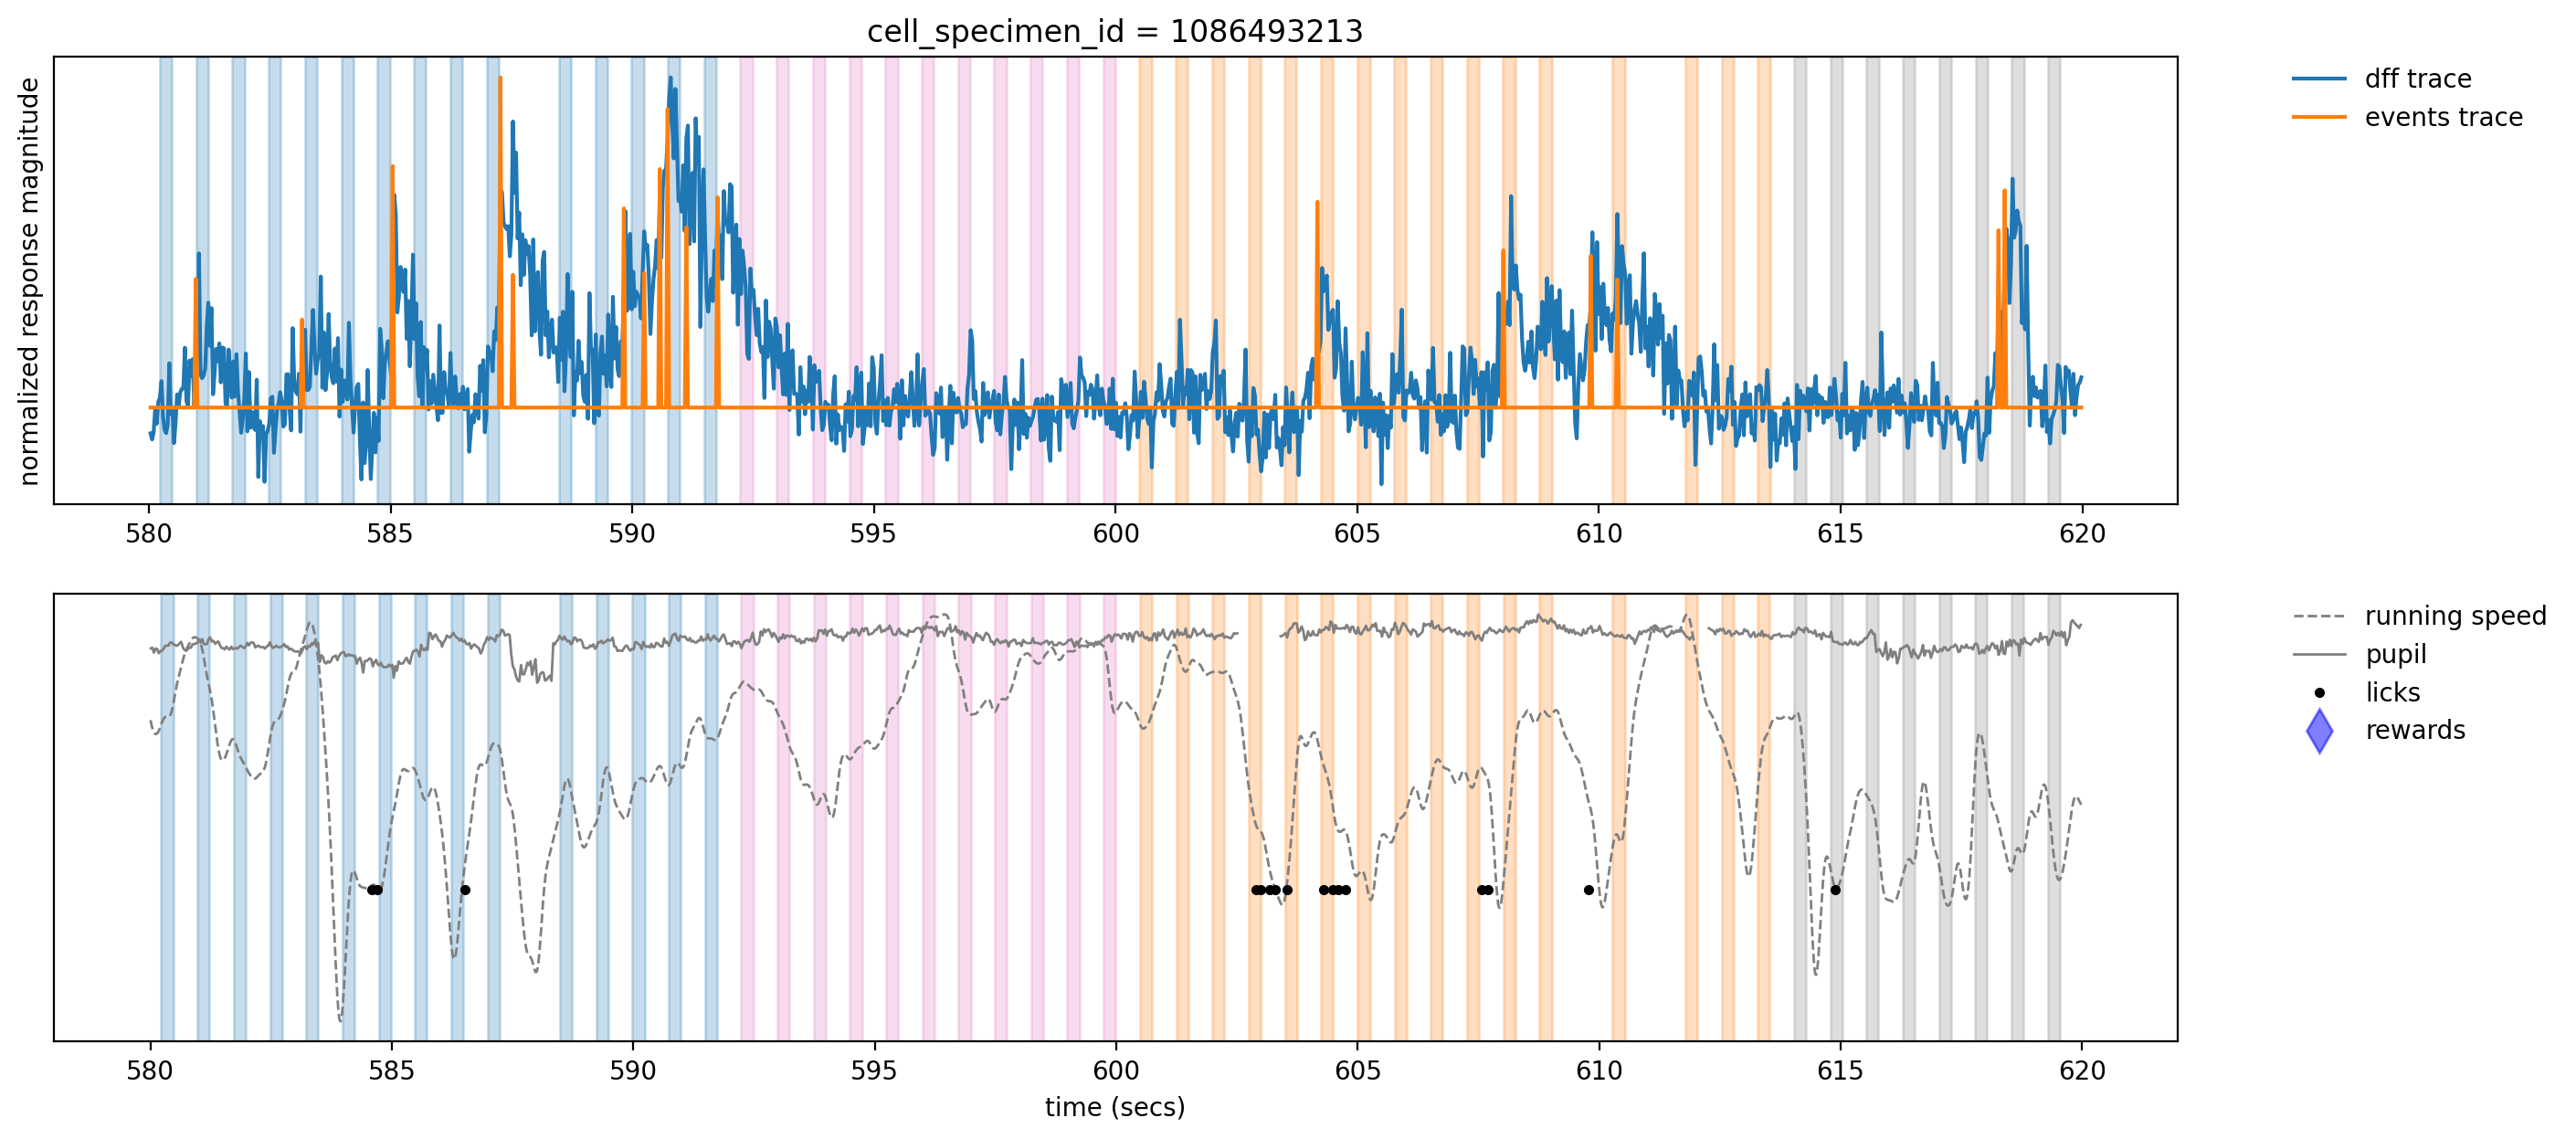

In [ ]:
# we can plot the same information for a different cell in the dataset
initial_time = 580 # start time in seconds
final_time = 620 # stop time in seconds
fig, ax = plt.subplots(2,1,figsize = (15,7))

plot_dff_trace(ax[0], cell_specimen_ids[5], initial_time, final_time)
plot_events_trace(ax[0], cell_specimen_ids[5], initial_time, final_time)
plot_stimuli(ax[0], initial_time, final_time)
ax[0].set_ylabel('normalized response magnitude')
ax[0].set_yticks([])
ax[0].set_title('cell_specimen_id = '+str(cell_specimen_ids[5]))
ax[0].legend(['dff trace', 'events trace'], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, frameon = False)

plot_running(ax[1], initial_time, final_time)
plot_pupil(ax[1], initial_time, final_time)
plot_licks(ax[1], initial_time, final_time)
plot_rewards(ax[1], initial_time, final_time)
plot_stimuli(ax[1], initial_time, final_time)

ax[1].set_yticks([])
ax[1].set_xlabel('time (secs)')
ax[1].legend(['running speed', 'pupil','licks', 'rewards'],bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, frameon = False);

In [ ]:
#@title Hidden
# This VIP neuron (9-10 minutes into session):
# active during our experiment but its activity does not appear to be reliably locked to image presentations as well
# Aligning neural activity to different behavioral or experimental events might reveal what this neuron is driven by

---
## Which images were shown on the trials above?
What if we want to know which images were shown here?

In [ ]:
 # from the stimulus presentation function to plot
stimulus_presentations_plot = stimulus_presentations.copy()
stimulus_presentations_plot = stimulus_presentations_plot[(stimulus_presentations_plot.end_time >= initial_time) & (stimulus_presentations_plot.start_time <= final_time)]
stimulus_presentations_plot.image_name.unique()

array(['im061', 'omitted', 'im077', 'im062', 'im085'], dtype=object)

Here is the table with this info- we an then use indices to find the data to plot for each image.

In [ ]:
ophys_experiment.stimulus_templates

,unwarped,warped
image_name,,
im065,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[198, 197, 201, 207, 207, 202, 198, 201, 207,..."
im077,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[129, 135, 140, 142, 140, 135, 129, 124, 117,..."
im066,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[83, 85, 82, 78, 78, 81, 84, 84, 82, 82, 84, ..."
im061,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[125, 126, 126, 126, 125, 125, 125, 125, 125,..."
im063,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[105, 108, 107, 101, 97, 96, 98, 101, 103, 10..."
im062,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[103, 103, 103, 105, 112, 125, 145, 172, 204,..."
im085,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[54, 56, 50, 45, 45, 51, 56, 55, 51, 48, 49, ..."
im069,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[251, 248, 255, 255, 255, 254, 246, 248, 255,..."


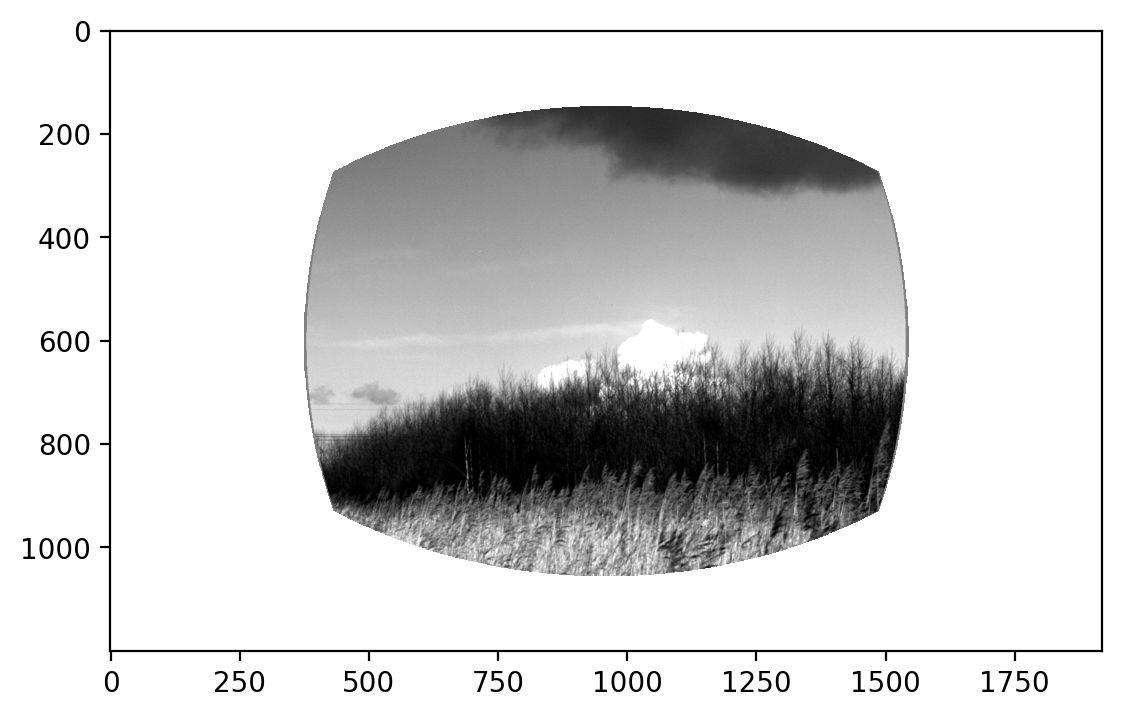

In [ ]:
# im061 is index 3
stimulus_templates = ophys_experiment.stimulus_templates.copy()
stimuli = stimulus_templates.index.values
plt.imshow(stimulus_templates.loc[stimuli[3]]['unwarped'], cmap='gray');

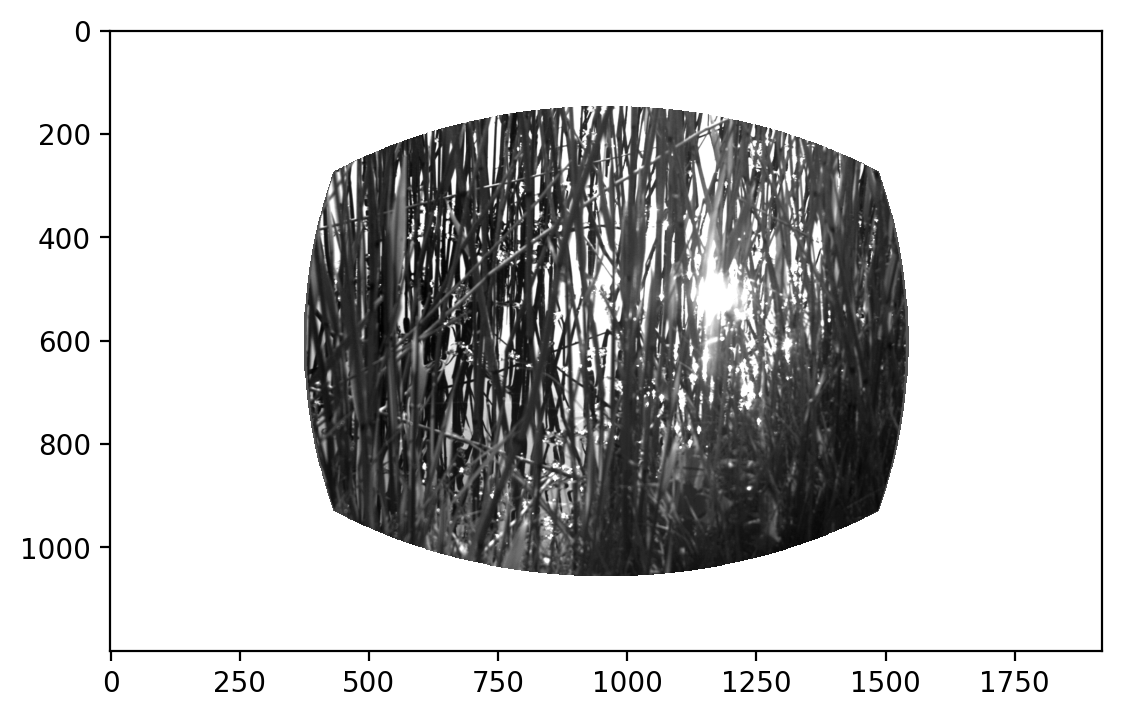

In [ ]:
# im077 is index 1
stimulus_templates = ophys_experiment.stimulus_templates.copy()
stimuli = stimulus_templates.index.values
plt.imshow(stimulus_templates.loc[stimuli[1]]['unwarped'], cmap='gray');

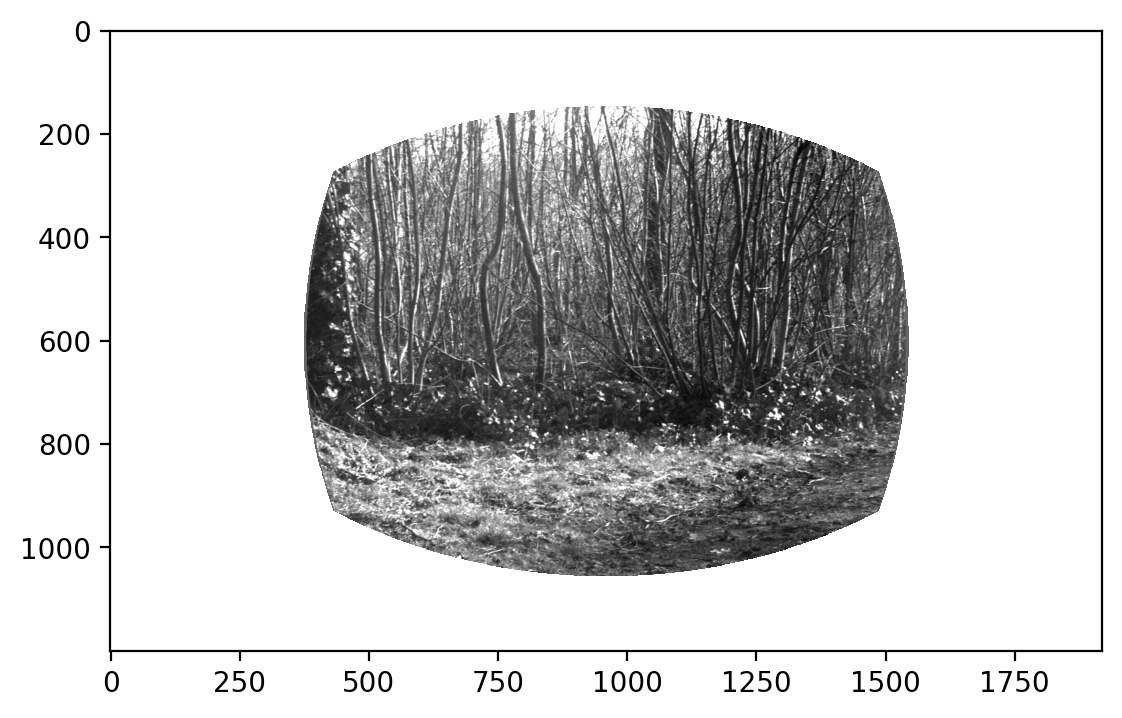

In [ ]:
# im062 is index 5
stimulus_templates = ophys_experiment.stimulus_templates.copy()
stimuli = stimulus_templates.index.values
plt.imshow(stimulus_templates.loc[stimuli[5]]['unwarped'], cmap='gray');

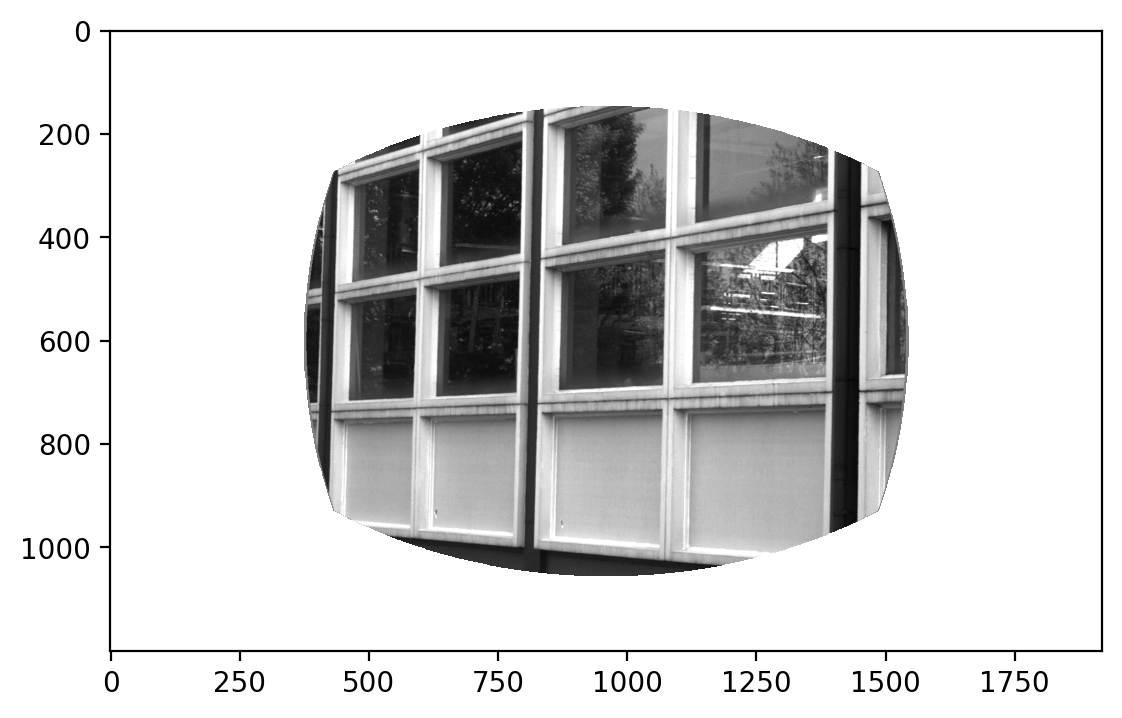

In [ ]:
# im085 is index 6
stimulus_templates = ophys_experiment.stimulus_templates.copy()
stimuli = stimulus_templates.index.values
plt.imshow(stimulus_templates.loc[stimuli[6]]['unwarped'], cmap='gray');

---
## Examining the data based on trial types:
* hit
* miss
* false alarm
* correct rejection

We will select responses to familiar images- ophys 1 images

In [ ]:
sessions = ophys_experiment_table.query('session_type == "OPHYS_1_images_A"')
sessions

,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_depth,targeted_structure,targeted_imaging_depth,imaging_plane_group,project_code,session_type,session_number,image_set,behavior_type,passive,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,published_at,isi_experiment_id,file_id
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
951980471,951520319,951410079,1018028342,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,150,VISp,150,0,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,0
951980473,951520319,951410079,1018028345,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISp,225,0,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,1
951980475,951520319,951410079,1018028339,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,75,VISp,75,1,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,2
951980479,951520319,951410079,1018028354,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,150,VISl,150,2,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,3
951980481,951520319,951410079,1018028357,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISl,225,2,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938002066,937825662,937682841,1018028405,453989,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),M,207,150,VISl,150,3,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,51,0,2019-09-03 13:44:25.200000+00:00,MESO.1,2021-03-25,848540715,1844
938002068,937825662,937682841,1018028408,453989,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),M,207,225,VISl,225,3,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,51,0,2019-09-03 13:44:25.200000+00:00,MESO.1,2021-03-25,848540715,1845
960957793,960834330,960749169,957024596,467302,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),M,173,290,VISp,290,<NA>,VisualBehavior,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,1,27,1,2019-10-03 14:14:10.253000+00:00,CAM2P.5,2021-03-25,894191516,1873


In [ ]:
# ophys_experiment_id
example_id = sessions[sessions.index == 946476556]
example_id

,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_depth,targeted_structure,targeted_imaging_depth,imaging_plane_group,project_code,session_type,session_number,image_set,behavior_type,passive,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,published_at,isi_experiment_id,file_id
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
946476556,946065801,945889501,939523510,457766,GCaMP6s,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,"[Slc17a7-IRES2-Cre, Camk2a-tTA]",Slc17a7-IRES2-Cre,Ai94(TITL-GCaMP6s),M,199,175,VISp,175,<NA>,VisualBehavior,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,2,60,2,2019-09-13 12:24:35.290000+00:00,CAM2P.3,2021-03-25,856448219,526


I've pre-selected an experiment id to use below

In [ ]:
# Select an id that used ophys 1 images A experiment
experiment_id = 946476556
print('getting experiment data for experiment_id {}'.format(experiment_id))

# this is new
experiment_dataset = cache.get_behavior_ophys_experiment(experiment_id)

getting experiment data for experiment_id 946476556


behavior_ophys_experiment_946476556.nwb: 100%|██████████| 2.05G/2.05G [01:51<00:00, 18.4MMB/s]
/usr/local/lib/python3.10/dist-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


---
## Review Data: Images

In [ ]:
stimulus_presentations = experiment_dataset.stimulus_presentations

In [ ]:
# Grab the change detection trials only
stimulus_presentations = experiment_dataset.stimulus_presentations[
    experiment_dataset.stimulus_presentations.stimulus_block_name.str.contains('change_detection')]
stimulus_presentations.head()

,stimulus_block,stimulus_block_name,image_index,image_name,movie_frame_index,duration,start_time,end_time,start_frame,end_frame,is_change,is_image_novel,omitted,movie_repeat,flashes_since_change,trials_id,stimulus_name,active,is_sham_change
stimulus_presentations_id,,,,,,,,,,,,,,,,,,,
1,1,change_detection_behavior,0,im065,-99,0.25023,305.992393,306.242623,17985,18000,False,False,False,-99,1,0,Natural_Images_Lum_Matched_set_training_2017,True,False
2,1,change_detection_behavior,8,omitted,-99,0.25000,306.743013,306.993013,18030,18045,False,<NA>,True,-99,1,0,Natural_Images_Lum_Matched_set_training_2017,True,False
3,1,change_detection_behavior,0,im065,-99,0.25021,307.493633,307.743843,18075,18090,False,False,False,-99,2,0,Natural_Images_Lum_Matched_set_training_2017,True,False
4,1,change_detection_behavior,0,im065,-99,0.25020,308.244253,308.494453,18120,18135,False,False,False,-99,3,0,Natural_Images_Lum_Matched_set_training_2017,True,False
5,1,change_detection_behavior,1,im077,-99,0.25023,308.994843,309.245073,18165,18180,True,False,False,-99,0,0,Natural_Images_Lum_Matched_set_training_2017,True,False


---
## Transform Calcium Imaging Data from Wide to Long Format

In [ ]:
# Review the calcium imaging data- in wide format
experiment_dataset.dff_traces

,cell_roi_id,dff
cell_specimen_id,,
1086677732,1080782769,"[0.19445239017441418, 0.12601236314041633, 0.1..."
1086677737,1080782784,"[0.20871294449813774, 0.3277438520090626, 0.14..."
1086677746,1080782868,"[0.2461564600926237, 0.2061539632478795, 0.183..."
1086677771,1080782948,"[0.23367534487212552, 0.22006350260557936, 0.2..."
1086677774,1080782973,"[1.1538649539919354, 0.5792651430717506, 0.386..."
...,...,...
1086681181,1080796630,"[0.3118437502741293, 0.24046091999409608, 0.29..."
1086681187,1080796635,"[0.26320051676444406, 0.2879916146643072, 0.23..."
1086681193,1080796640,"[0.20019075067103015, 0.24754917014788463, 0.2..."


Here is an example function that does the transformation to put the data into a dataframe in long format.<br>
This will take several minutes to run- it's alot of data!

In [ ]:
#@title Hidden Function to transfrom data from wide format into long format
def get_cell_timeseries_dict(dataset, cell_specimen_id):
    '''
    for a given cell_specimen ID, this function creates a dictionary with the following keys
    * timestamps: ophys timestamps
    * cell_roi_id
    * cell_specimen_id
    * dff
    This is useful for generating a tidy dataframe
    arguments:
        session object
        cell_specimen_id
    returns
        dict
    '''
    cell_dict = {
        'timestamps': dataset.ophys_timestamps,
        'cell_roi_id': [dataset.dff_traces.loc[cell_specimen_id]['cell_roi_id']] * len(dataset.ophys_timestamps),
        'cell_specimen_id': [cell_specimen_id] * len(dataset.ophys_timestamps),
        'dff': dataset.dff_traces.loc[cell_specimen_id]['dff'],

    }
    return cell_dict

experiment_dataset.tidy_dff_traces = pd.concat(
    [pd.DataFrame(get_cell_timeseries_dict(experiment_dataset, cell_specimen_id)) for cell_specimen_id in experiment_dataset.dff_traces.reset_index()['cell_specimen_id']]
).reset_index(drop=True)

experiment_dataset.tidy_dff_traces.sample(5, random_state=42)

,timestamps,cell_roi_id,cell_specimen_id,dff
13992012,3975.16993,1080785595,1086678641,0.000000
19454981,3955.16389,1080787632,1086679007,0.014629
29176119,1198.32894,1080791352,1086679651,0.005999
4548933,2135.72548,1080783737,1086678067,0.039479
44958058,4159.84637,1080795700,1086677245,-0.082793


### Walkthrough of function


If you are interested in walking through what the above function is doing step by step, review the code cells below.

In [ ]:
# first we need to see what cell specimen ids we have to choose from
experiment_dataset.dff_traces.head()

,cell_roi_id,dff
cell_specimen_id,,
1086677732,1080782769,"[0.19445239017441418, 0.12601236314041633, 0.1..."
1086677737,1080782784,"[0.20871294449813774, 0.3277438520090626, 0.14..."
1086677746,1080782868,"[0.2461564600926237, 0.2061539632478795, 0.183..."
1086677771,1080782948,"[0.23367534487212552, 0.22006350260557936, 0.2..."
1086677774,1080782973,"[1.1538649539919354, 0.5792651430717506, 0.386..."


In [ ]:
# choose one to test out the code within the function- cell specimen id is an input to the function
# Find the cell_roi_id corresponding to the cell_specimen_id and then repeat that number the length of rows we have for the ophys timestamps
cell_specimen_id = 1086677732
test = experiment_dataset.dff_traces.loc[cell_specimen_id]['cell_roi_id']
test

1080782769

In [ ]:
# Do the same thing but using the cell_specimen_id- this is used in the broader loop and defined there each time
[cell_specimen_id] * len(experiment_dataset.ophys_timestamps)

In [ ]:
# trace data
experiment_dataset.dff_traces.loc[cell_specimen_id]['dff']

array([0.19445239, 0.12601236, 0.18939316, ..., 0.09283477, 0.14407277,
       0.24868093])

The above values are all arrays (dict) and then get put into a dataframe

---
## Plotting
Define a function to plot for each type of data:

* each stimulus as a colored vertical bar<br>
* running speed<br>
* licks/rewards<br>
* pupil area<br>
* neural responses (dF/F)<br>

In [ ]:
#@title Hidden Code - Image Colors for Plot
# similar code to above- makes a color for each image name for plots (vertical bars)
unique_stimuli = [stimulus for stimulus in stimulus_presentations['image_name'].unique() if stimulus != 'omitted']
colormap = {image_name: sns.color_palette()[image_number] for image_number, image_name in enumerate(np.sort(unique_stimuli))}
colormap['omitted'] = np.nan # assign gray to omitted
stimulus_presentations['color'] = stimulus_presentations['image_name'].map(lambda image_name: colormap[image_name])

In [ ]:
#@title Hidden Code - Defining Functions to Plot
def plot_stimuli(trial, ax):
    '''
    plot stimuli as colored bars on specified axis
    '''
    # Fixup type for use in query.
    stimulus_presentations['omitted'] = stimulus_presentations['omitted'].astype('bool')
    stimuli = stimulus_presentations.query('end_time >= {} and start_time <= {} and not omitted'.format(float(trial['start_time']), float(trial['stop_time'])))
    for idx, stimulus in stimuli.iterrows():
        ax.axvspan(stimulus['start_time'], stimulus['end_time'], color=stimulus['color'], alpha=0.5)


def plot_running(trial, ax):
    '''
    plot running speed for trial on specified axes
    '''
    trial_running_speed = experiment_dataset.running_speed.query('timestamps >= {} and timestamps <= {} '.format(float(trial['start_time']), float(trial['stop_time'])))
    ax.plot(
        trial_running_speed['timestamps'],
        trial_running_speed['speed'],
        color='black'
    )
    #ax.set_title('running speed')
    #ax.set_ylabel('speed (cm/s)')


def plot_licks(trial, ax):
    '''
    plot licks as black dots on specified axis
    '''
    trial_licks = experiment_dataset.licks.query('timestamps >= {} and timestamps <= {} '.format(float(trial['start_time']), float(trial['stop_time'])))
    ax.plot(
        trial_licks['timestamps'],
        np.zeros_like(trial_licks['timestamps']),
        marker = 'o',
        linestyle = 'none',
        color='black'
    )


def plot_rewards(trial, ax):
    '''
    plot rewards as blue diamonds on specified axis
    '''
    trial_rewards = experiment_dataset.rewards.query('timestamps >= {} and timestamps <= {} '.format(float(trial['start_time']), float(trial['stop_time'])))
    ax.plot(
        trial_rewards['timestamps'],
        np.zeros_like(trial_rewards['timestamps']),
        marker = 'd',
        linestyle = 'none',
        color='blue',
        markersize = 10,
        alpha = 0.25
    )

def plot_pupil(trial, ax):
    '''
    plot pupil area on specified axis
    '''
    trial_eye_tracking = experiment_dataset.eye_tracking.query('timestamps >= {} and timestamps <= {} '.format(float(trial['start_time']), float(trial['stop_time'])))
    ax.plot(
        trial_eye_tracking['timestamps'],
        trial_eye_tracking['pupil_area'],
        color='black'
    )
    #ax.set_title('pupil area')
    #ax.set_ylabel('pupil area\n')


def plot_dff(trial, ax):
    '''
    plot each cell's dff response for a given trial
    '''
    trial_dff_traces = experiment_dataset.tidy_dff_traces.query('timestamps >= {} and timestamps <= {} '.format(float(trial['start_time']), float(trial['stop_time'])))
    for cell_specimen_id in experiment_dataset.tidy_dff_traces['cell_specimen_id'].unique():
        ax.plot(
            trial_dff_traces.query('cell_specimen_id == @cell_specimen_id')['timestamps'],
            trial_dff_traces.query('cell_specimen_id == @cell_specimen_id')['dff']
        )
        #ax.set_title('deltaF/F responses')
        #ax.set_ylabel('dF/F')

## Not currently using this function- plotting individually below and adjusting axes, legend
## If using this function, the legend shapes for rewards and licks do not show up properly
def make_trial_plot(trial):
    '''
    combine all plots for a given trial
    '''
    fig, axes = plt.subplots(4, 1, figsize = (15, 8), sharex=True)

    for ax in axes:
        plot_stimuli(trial, ax)

    plot_running(trial, axes[0])

    plot_licks(trial, axes[1])
    plot_rewards(trial, axes[1])

    axes[1].set_title('licks and rewards')
    axes[1].set_yticks([])
    axes[1].legend(['licks','rewards'],frameon = False);


    plot_pupil(trial, axes[2])

    plot_dff(trial, axes[3])

    axes[3].set_xlabel('time in session (seconds)')
    fig.tight_layout()
    return fig, axes

## Trialtype 1: What type of trial is this?

trial id chosen: 464


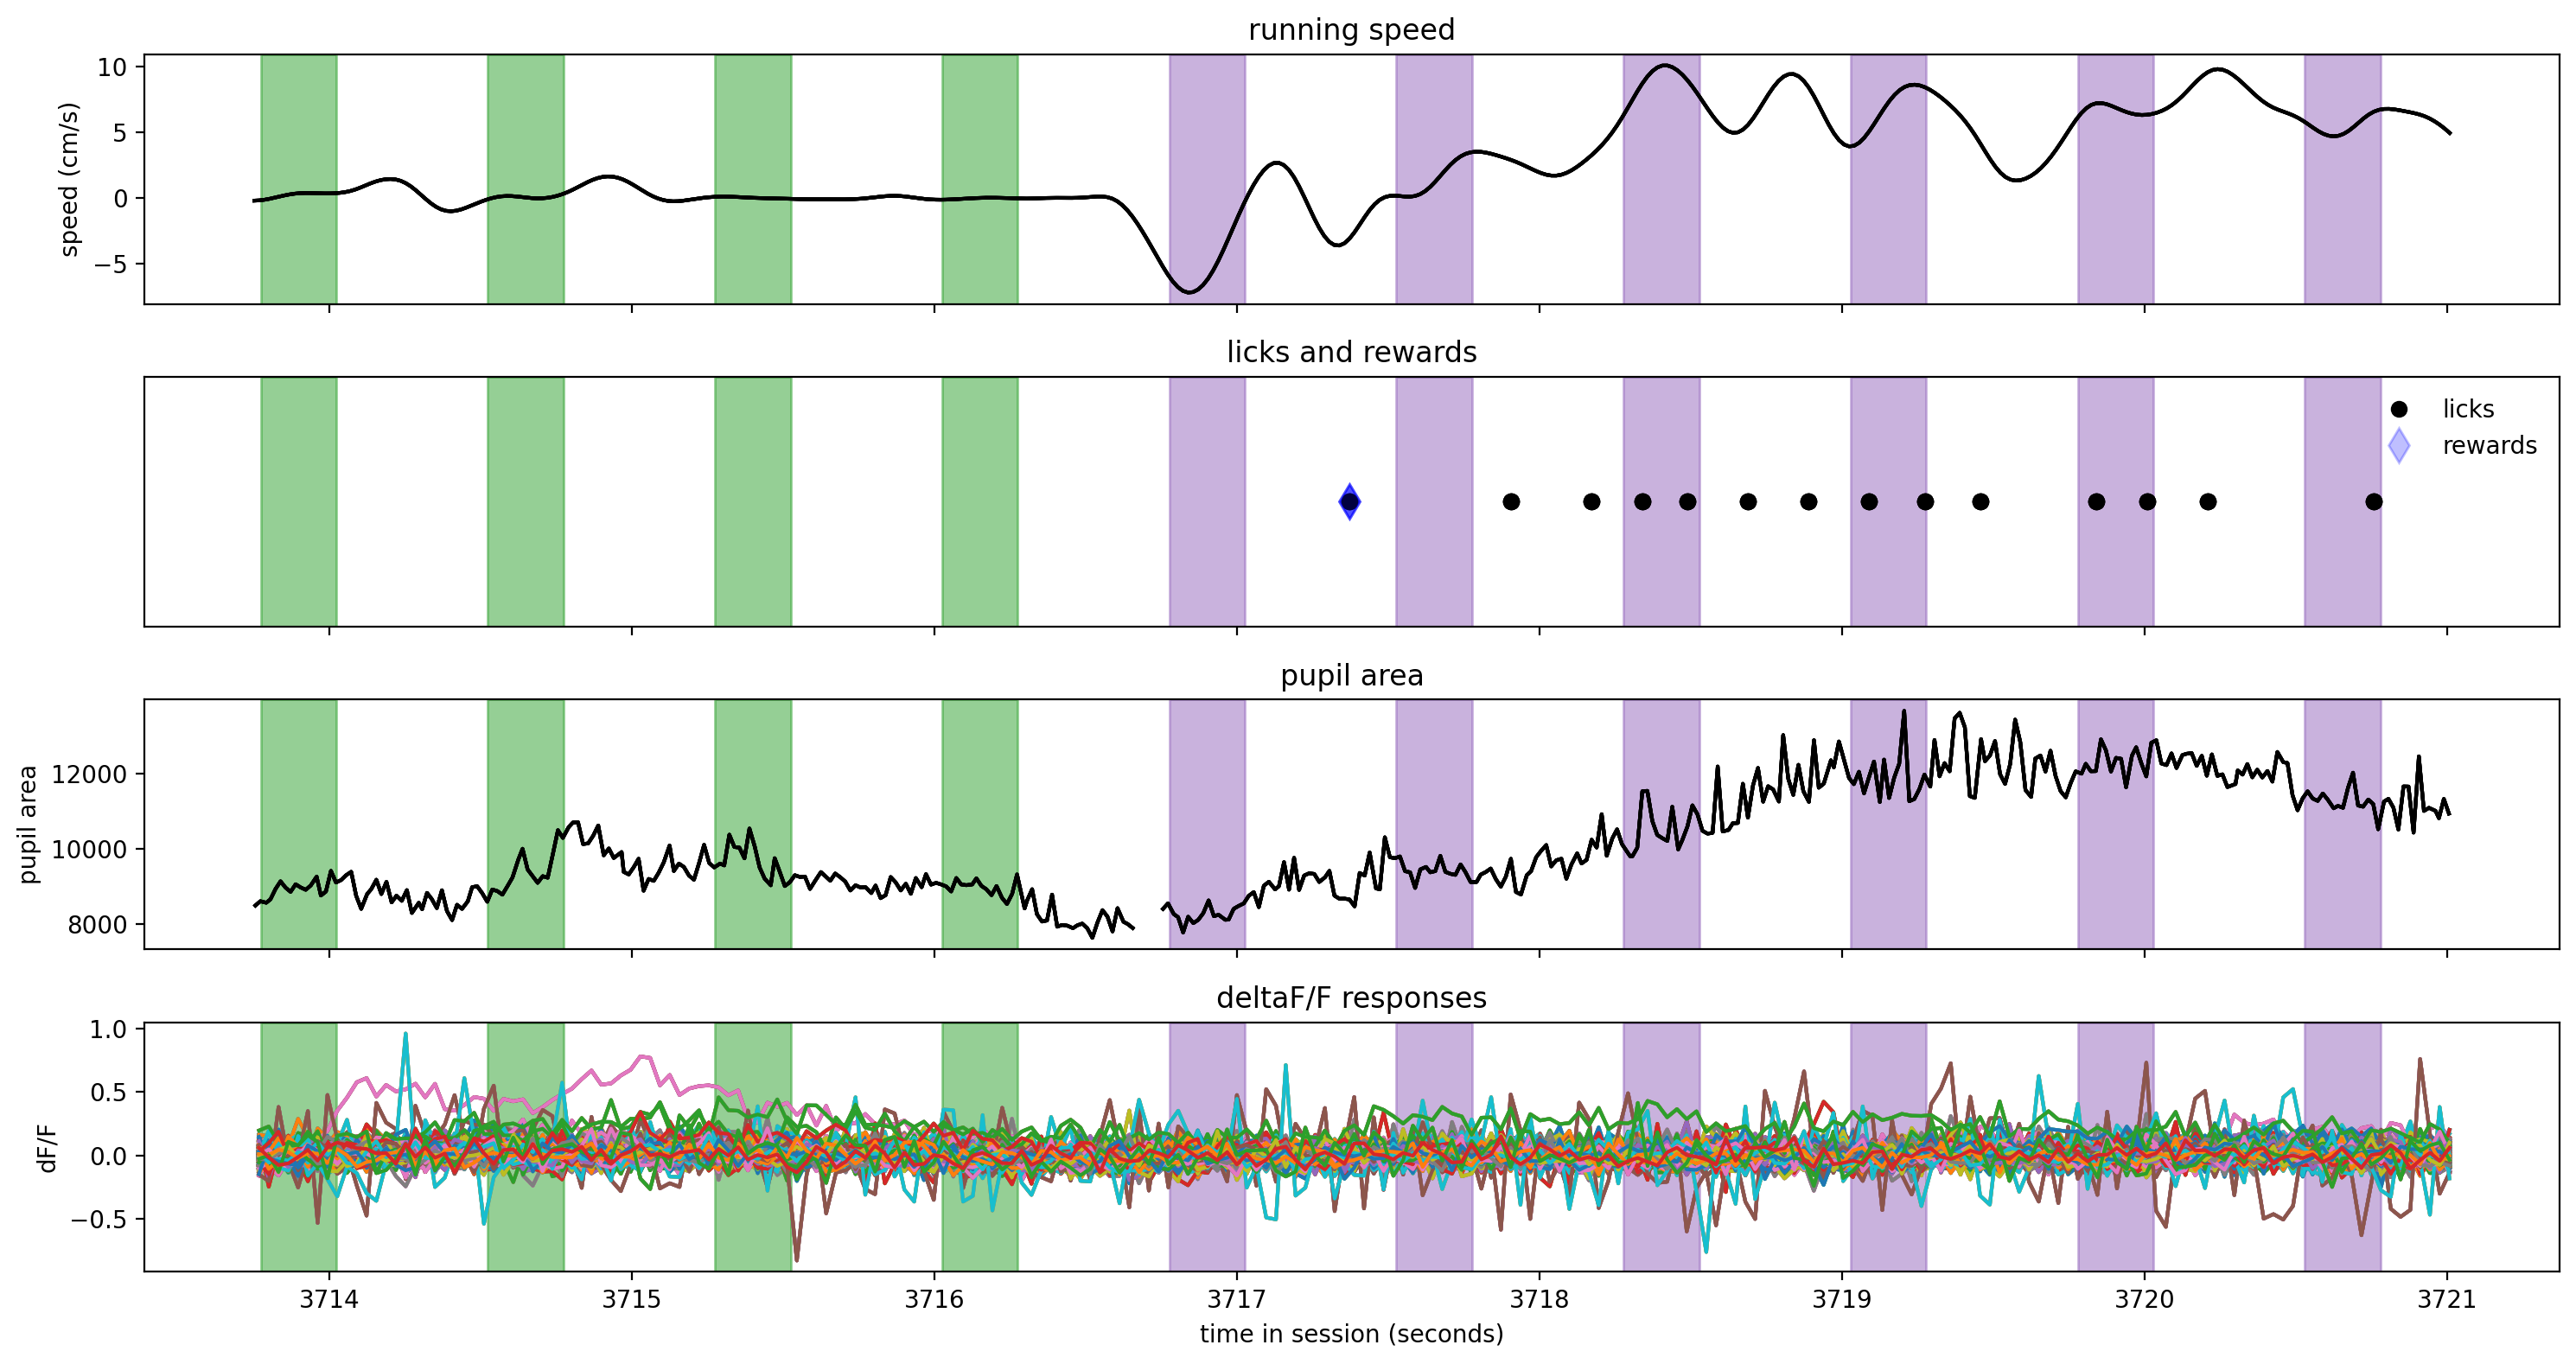

In [ ]:
#@title Hidden Plotting Code
# Plotting hit trial
trial = experiment_dataset.trials.query('hit').sample(random_state = 12)
print('trial id chosen:', trial.index[0])

fig, axes = plt.subplots(4, 1, figsize = (15, 8), sharex=True)

for ax in axes:
  plot_stimuli(trial, ax)

  plot_running(trial, axes[0])
  axes[0].set_title('running speed')
  axes[0].set_ylabel('speed (cm/s)')

  plot_licks(trial, axes[1])
  plot_rewards(trial, axes[1])
  axes[1].set_title('licks and rewards')
  axes[1].set_yticks([])
  axes[1].legend(['licks','rewards'], frameon = False);

  plot_pupil(trial, axes[2])
  axes[2].set_title('pupil area')
  axes[2].set_ylabel('pupil area')

  plot_dff(trial, axes[3])
  axes[3].set_title('deltaF/F responses')
  axes[3].set_ylabel('dF/F')

  axes[3].set_xlabel('time in session (seconds)')
  fig.tight_layout()

In [ ]:
trial

,start_time,stop_time,initial_image_name,change_image_name,is_change,change_time,go,catch,lick_times,response_time,response_latency,reward_time,reward_volume,hit,false_alarm,miss,correct_reject,aborted,auto_rewarded,change_frame,trial_length
trials_id,,,,,,,,,,,,,,,,,,,,,
464,3713.75139,3721.00733,im063,im066,True,3716.775363,True,False,"[3717.37101, 3717.90478, 3718.17166, 3718.3384...",3717.37101,0.595647,3717.37101,0.007,True,False,False,False,False,False,222465,7.25594


## Trialtype 2: What type of trial is this?

trial id chosen: 307


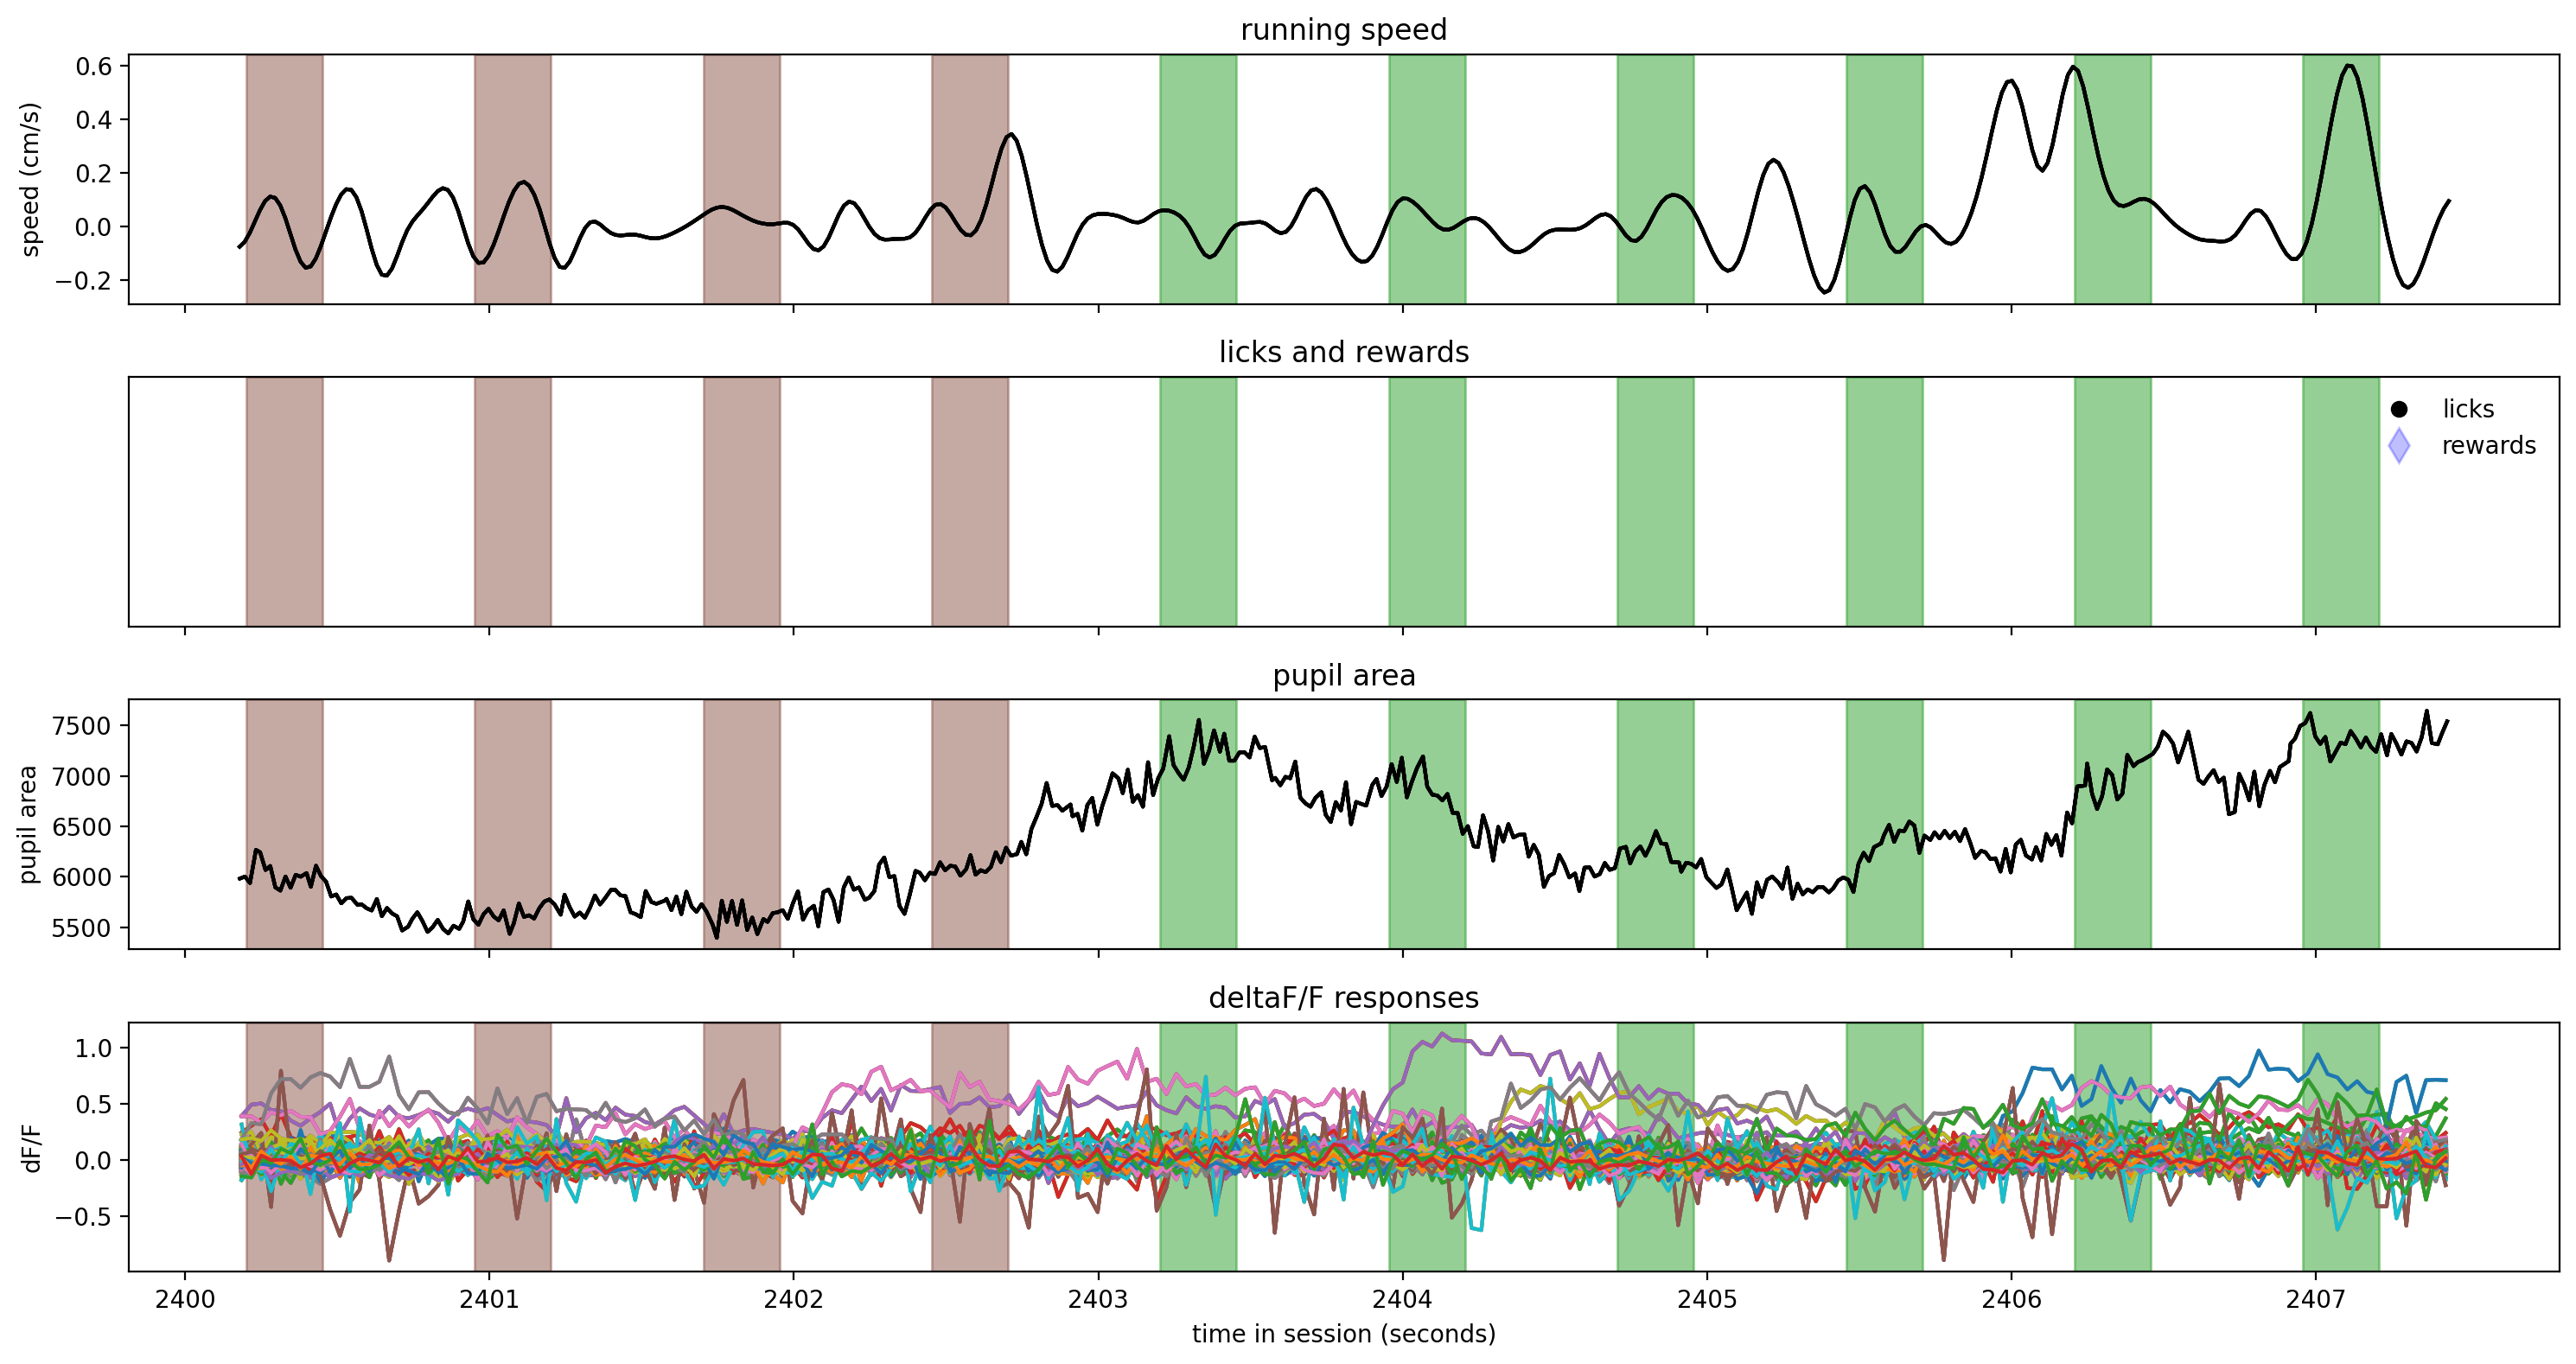

In [ ]:
#@title Hidden Plotting Code
trial = experiment_dataset.trials.query('miss').sample(random_state = 12)
print('trial id chosen:', trial.index[0])

fig, axes = plt.subplots(4, 1, figsize = (15, 8), sharex=True)

for ax in axes:
  plot_stimuli(trial, ax)

  plot_running(trial, axes[0])
  axes[0].set_title('running speed')
  axes[0].set_ylabel('speed (cm/s)')

  plot_licks(trial, axes[1])
  plot_rewards(trial, axes[1])
  axes[1].set_title('licks and rewards')
  axes[1].set_yticks([])
  axes[1].legend(['licks','rewards'], frameon = False);

  plot_pupil(trial, axes[2])
  axes[2].set_title('pupil area')
  axes[2].set_ylabel('pupil area')

  plot_dff(trial, axes[3])
  axes[3].set_title('deltaF/F responses')
  axes[3].set_ylabel('dF/F')

  axes[3].set_xlabel('time in session (seconds)')
  fig.tight_layout()

## Trialtype 3: What type of trial is this?

trial id chosen: 53


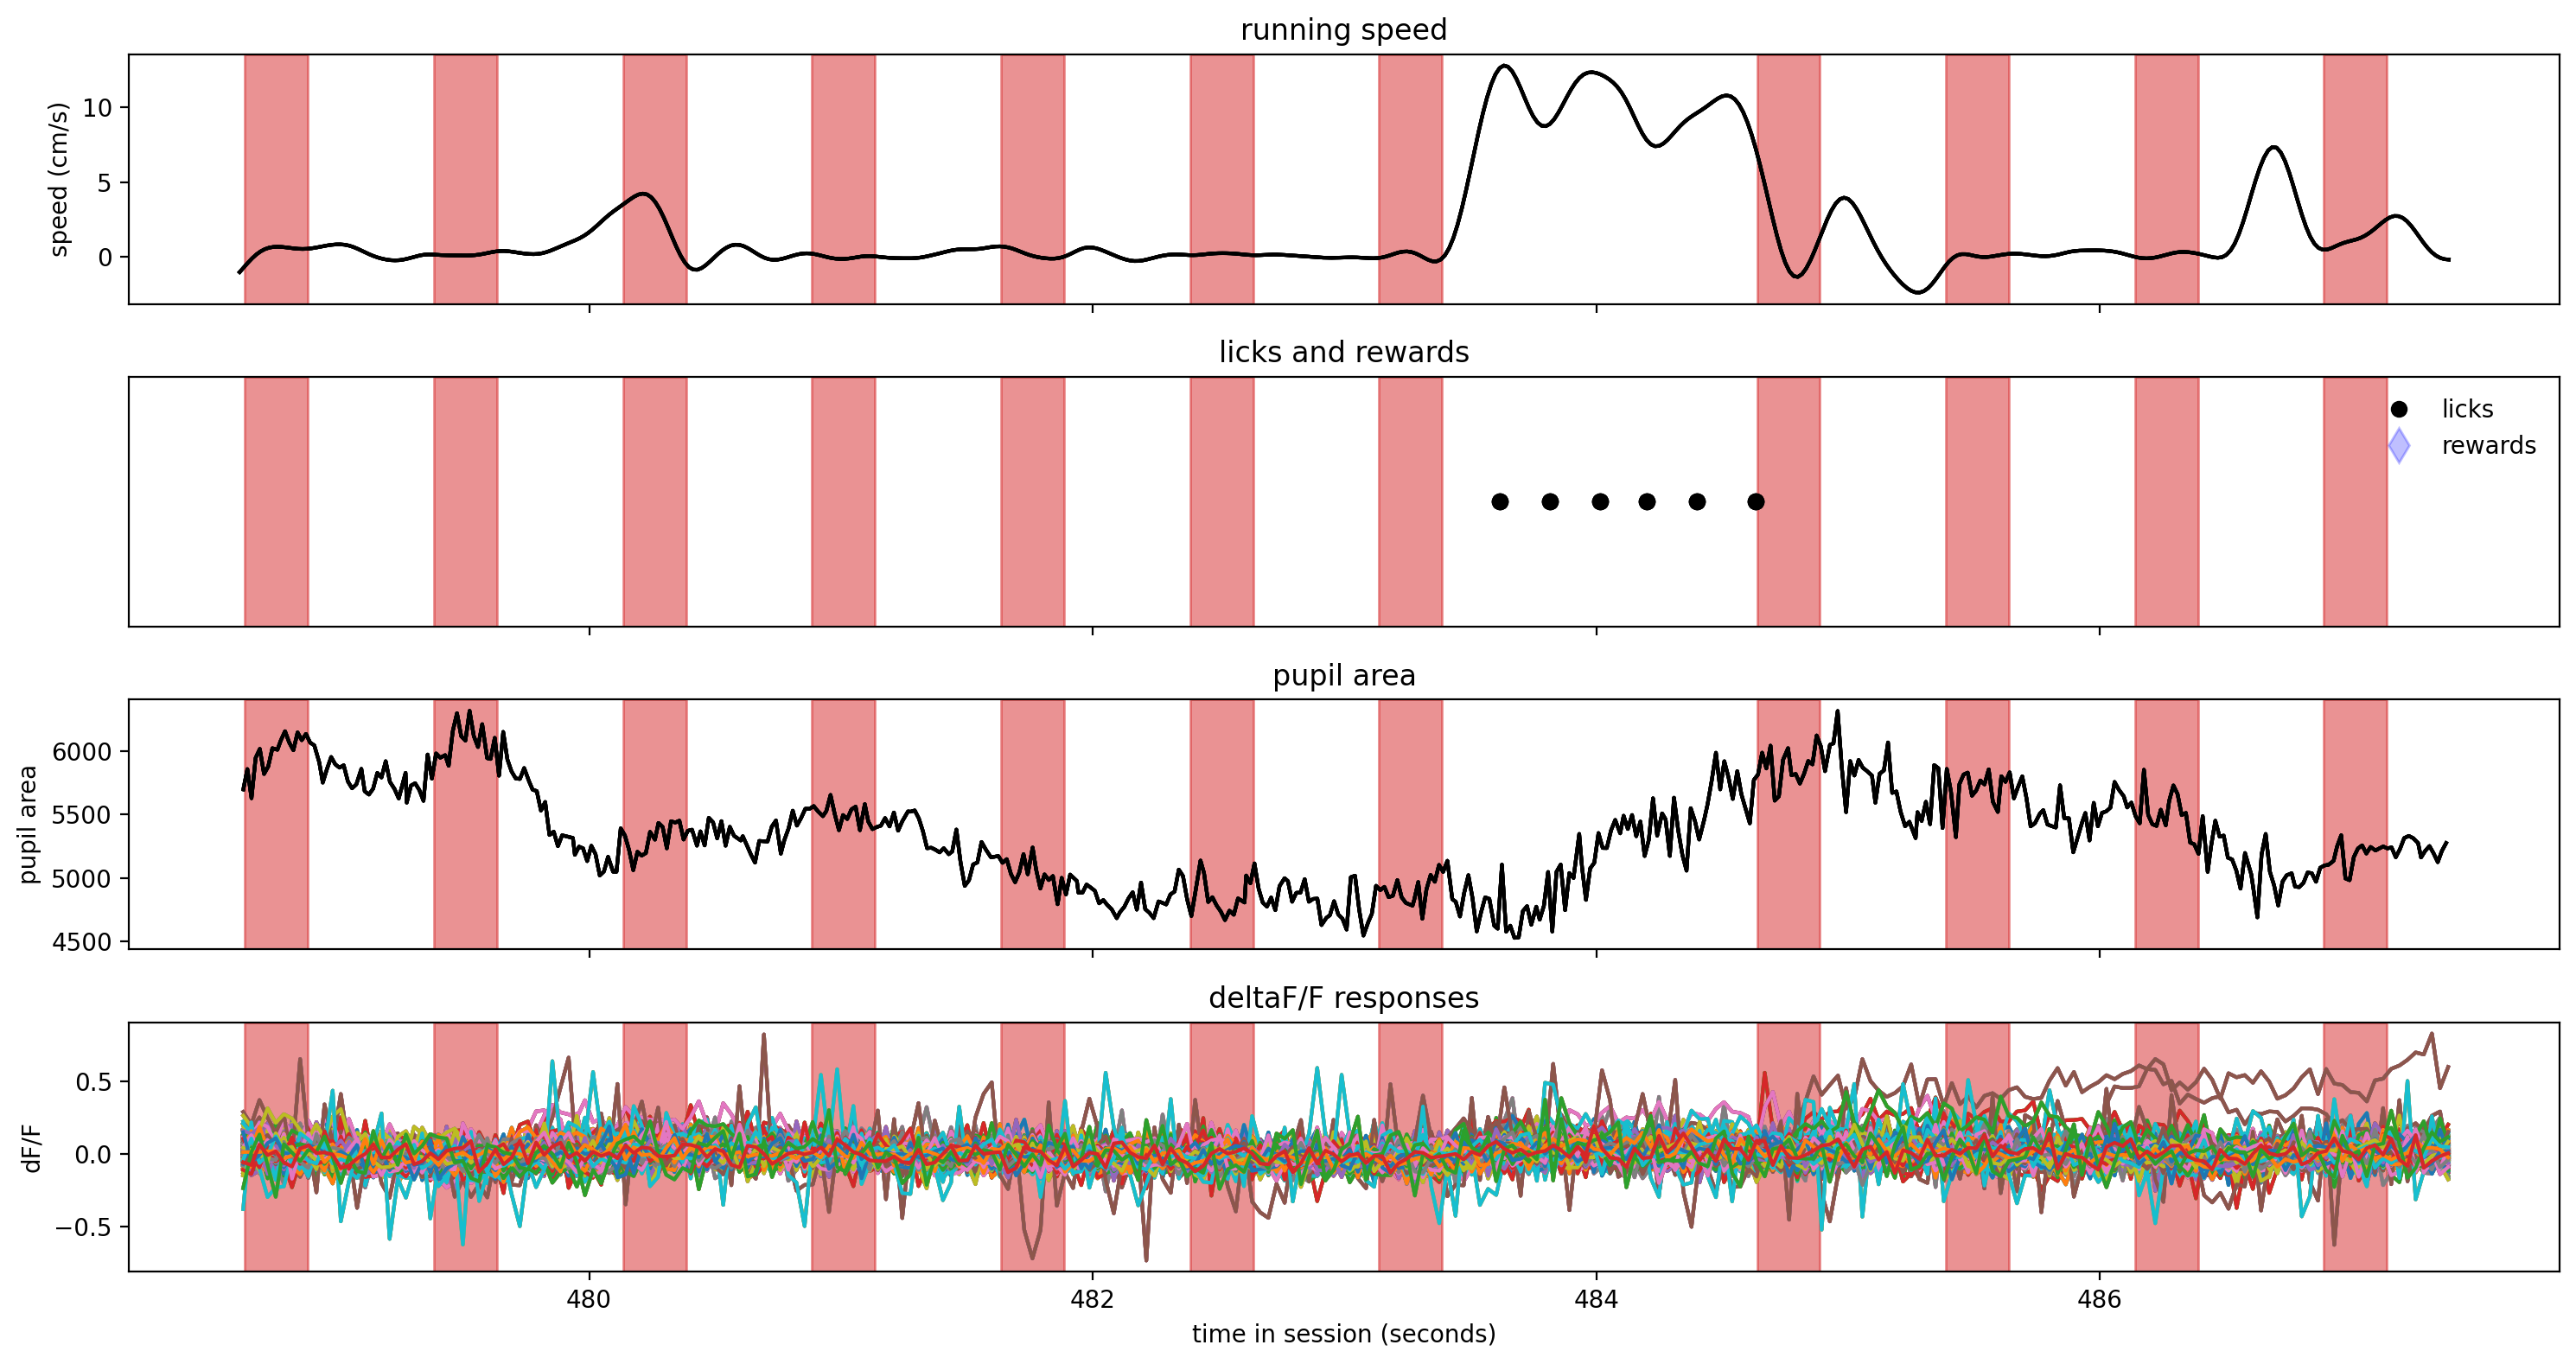

In [ ]:
#@title Hidden Plotting Code
trial = experiment_dataset.trials.query('false_alarm').sample(random_state = 12)
print('trial id chosen:', trial.index[0])

fig, axes = plt.subplots(4, 1, figsize = (15, 8), sharex=True)

for ax in axes:
  plot_stimuli(trial, ax)

  plot_running(trial, axes[0])
  axes[0].set_title('running speed')
  axes[0].set_ylabel('speed (cm/s)')

  plot_licks(trial, axes[1])
  plot_rewards(trial, axes[1])
  axes[1].set_title('licks and rewards')
  axes[1].set_yticks([])
  axes[1].legend(['licks','rewards'], frameon = False);

  plot_pupil(trial, axes[2])
  axes[2].set_title('pupil area')
  axes[2].set_ylabel('pupil area')

  plot_dff(trial, axes[3])
  axes[3].set_title('deltaF/F responses')
  axes[3].set_ylabel('dF/F')

  axes[3].set_xlabel('time in session (seconds)')
  fig.tight_layout()

## Trialtype 4: What type of trial is this?

trial id chosen: 366


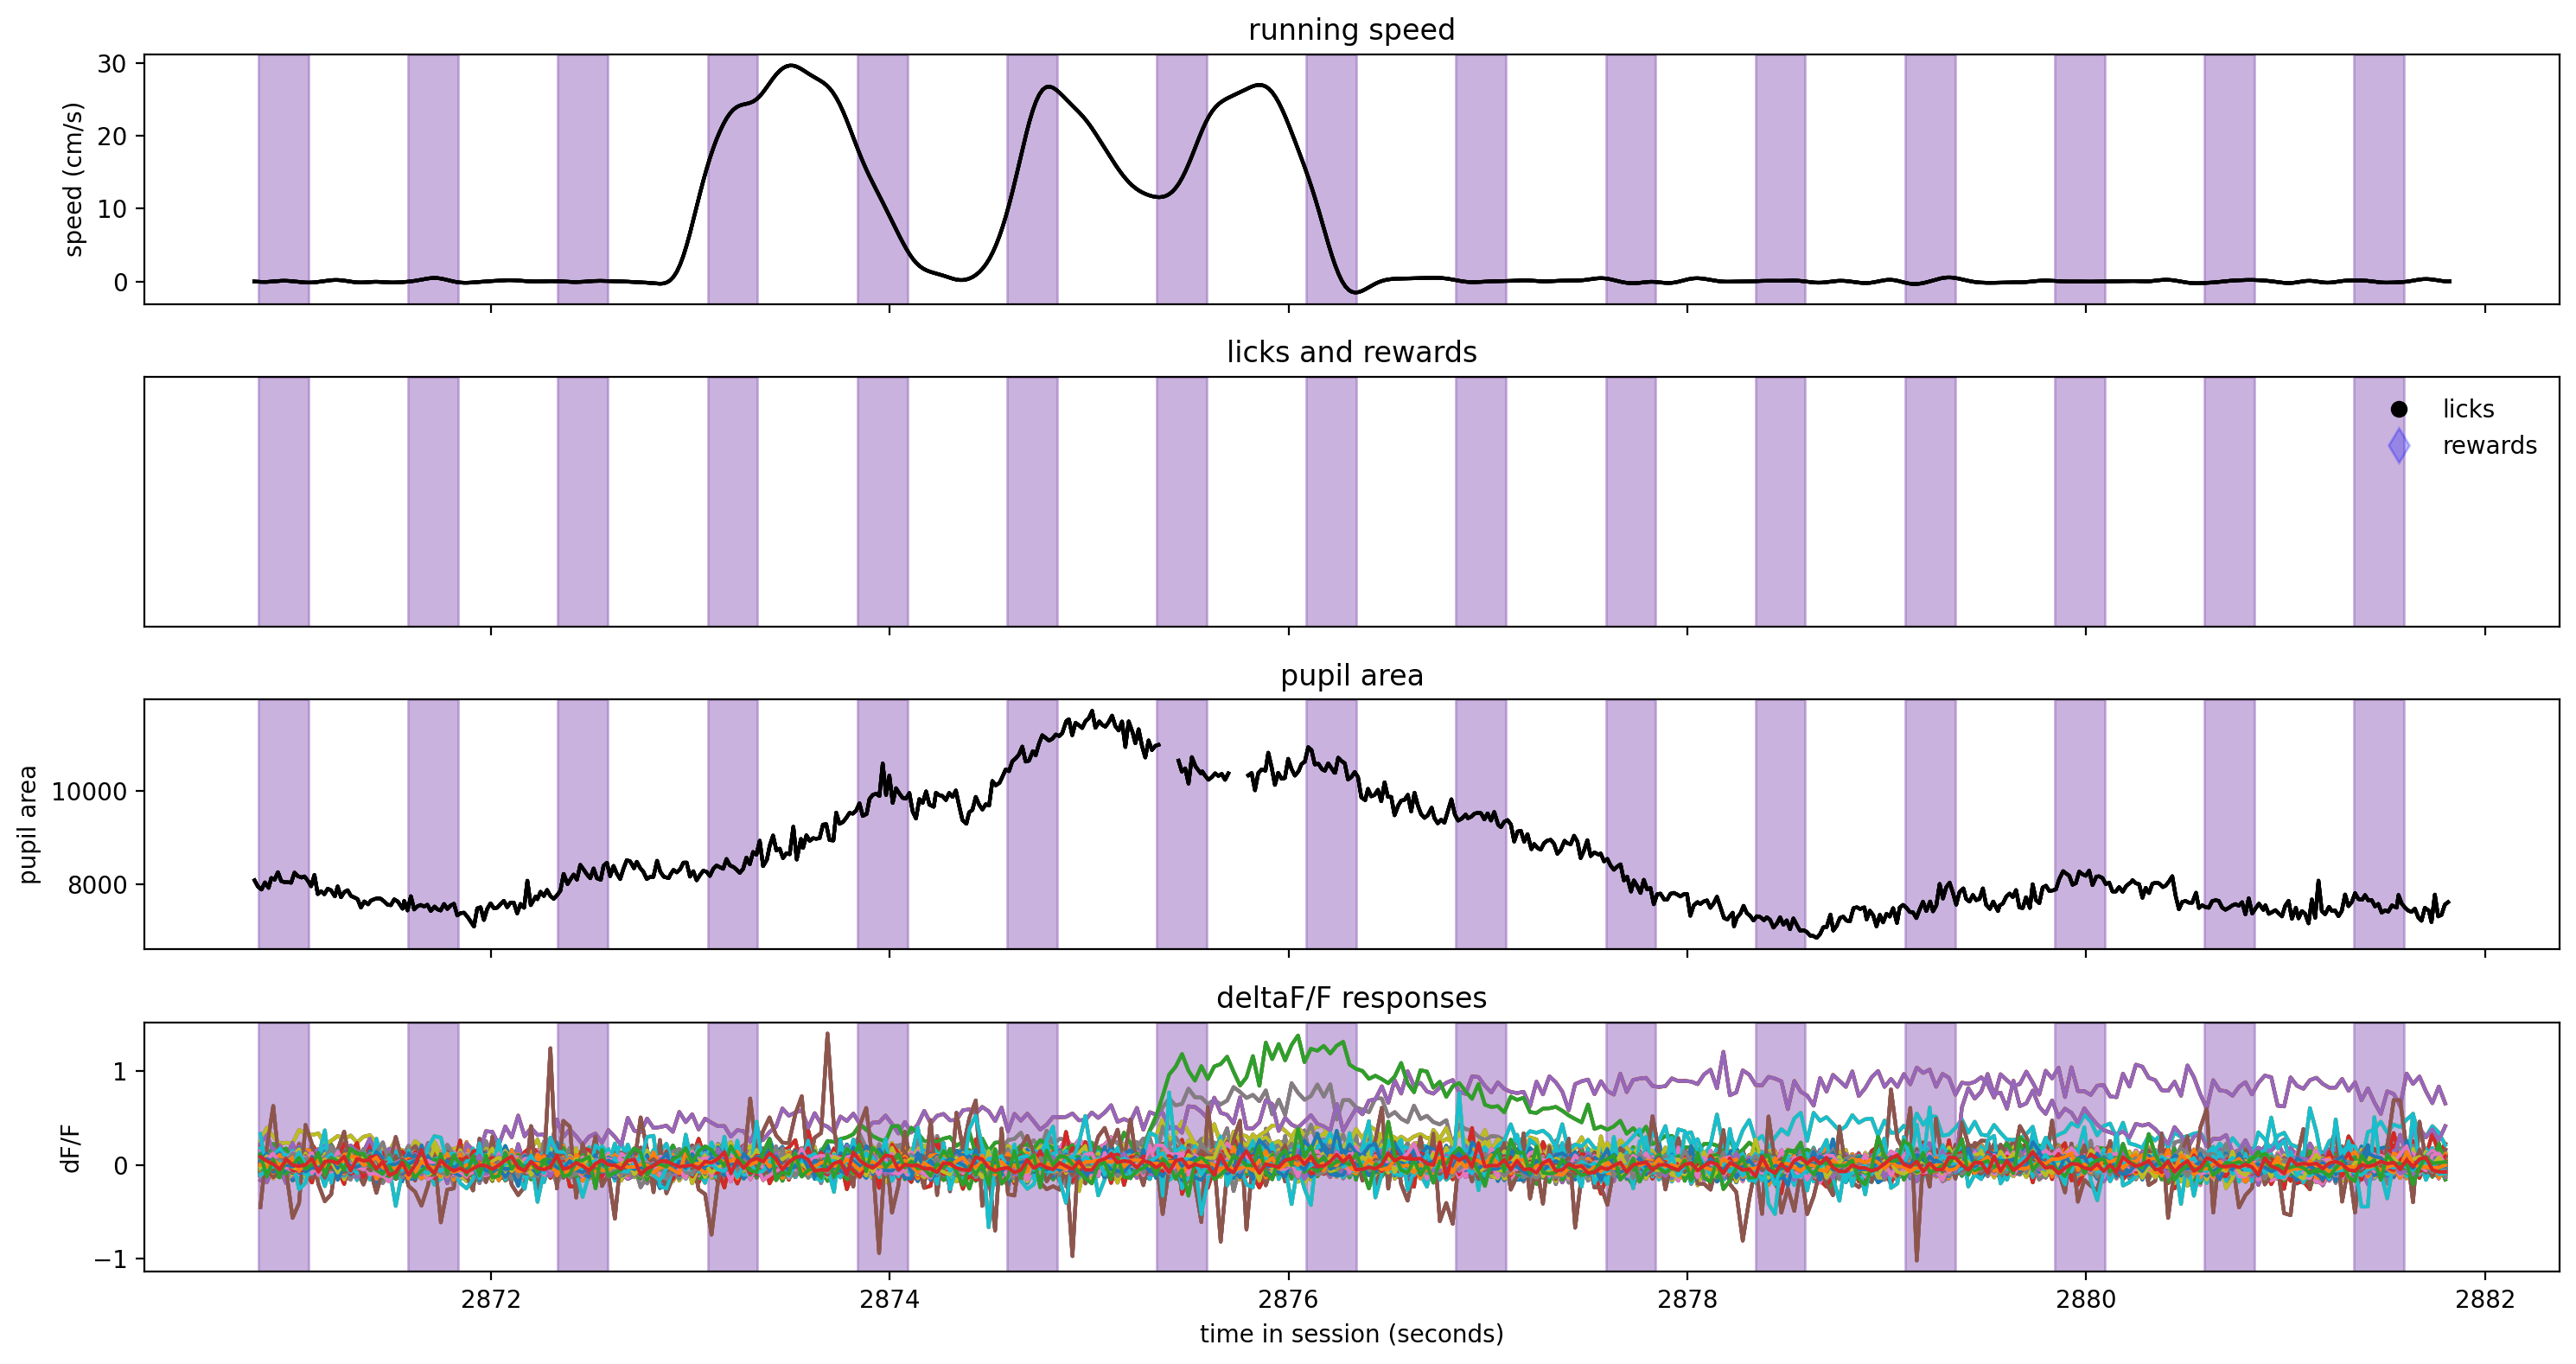

In [ ]:
#@title Hidden Plotting Code
trial = experiment_dataset.trials.query('correct_reject').sample(random_state = 12)
print('trial id chosen:', trial.index[0])

fig, axes = plt.subplots(4, 1, figsize = (15, 8), sharex=True)

for ax in axes:
  plot_stimuli(trial, ax)

  plot_running(trial, axes[0])
  axes[0].set_title('running speed')
  axes[0].set_ylabel('speed (cm/s)')

  plot_licks(trial, axes[1])
  plot_rewards(trial, axes[1])
  axes[1].set_title('licks and rewards')
  axes[1].set_yticks([])
  axes[1].legend(['licks','rewards'], frameon = False);

  plot_pupil(trial, axes[2])
  axes[2].set_title('pupil area')
  axes[2].set_ylabel('pupil area')

  plot_dff(trial, axes[3])
  axes[3].set_title('deltaF/F responses')
  axes[3].set_ylabel('dF/F')

  axes[3].set_xlabel('time in session (seconds)')
  fig.tight_layout()
